# Action / transition CDs (4 axes)

Build four coding-direction axes from the **previous-choice × upcoming-choice** 2×2 design, balanced at the cell level so each axis is orthogonalized w.r.t. the other factors.

| | Upcoming L | Upcoming R |
|---|---|---|
| **Prev L** | `L_L` (stay) | `switch_LR` |
| **Prev R** | `switch_RL` | `R_R` (stay) |

Per session we subsample the four cells to `n = min(|cell|)` trials, then fit four CDs:

| Axis | A (positive) | B (negative) |
|---|---|---|
| `prev_choice`  | Prev L (`L_L ∪ switch_LR`) | Prev R (`switch_RL ∪ R_R`) |
| `up_choice`    | Up L  (`L_L ∪ switch_RL`) | Up R  (`switch_LR ∪ R_R`) |
| `switch_stay`  | Switch (`switch_LR ∪ switch_RL`) | Stay (`L_L ∪ R_R`) |
| `switch_dir`   | `switch_LR` | `switch_RL` |

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

MODULE_PATH = Path("/root/capsule/src/aind_dft_ephys_analysis")
if str(MODULE_PATH) not in sys.path:
    sys.path.insert(0, str(MODULE_PATH))

print(f"Modules loaded from: {MODULE_PATH}")

Modules loaded from: /root/capsule/src/aind_dft_ephys_analysis


In [2]:
# ALM recordings — sessions of interest
sessions = [
    "ecephys_844034_2026-05-05_12-26-26_sorted_2026-05-13_16-51-38",
    "ecephys_844034_2026-05-06_12-31-42_sorted_2026-05-10_00-09-35",
    "ecephys_844034_2026-05-07_12-26-08_sorted_2026-05-10_22-15-43",
    "ecephys_844036_2026-05-04_16-06-43_sorted_2026-05-09_21-00-45",
    "ecephys_844036_2026-05-05_16-08-08_sorted_2026-05-19_17-42-51",
    "ecephys_844036_2026-05-06_16-27-46_sorted_2026-05-10_00-06-13",
]

## 1. Build the 4 balanced action/transition CDs

`build_action_transition_cds` does it all per session:
  1. read the `L_L_trials`, `switch_LR_trials`, `switch_RL_trials`, `R_R_trials` columns from each behavior CSV,
  2. subsample each of those four cells to a common `n = min(…)` (deterministic with `seed`),
  3. write the balanced cells *and* the four axis unions back into the CSV as new `*_balanced_trials` columns,
  4. invoke `build_cd_dataset` once per axis so you get four CD zarrs per session/region/window.

In [3]:
from pathlib import Path
from ephys_dimension_reduction_CD_pipeline import (
    build_action_transition_cds,
    ACTION_AXES,
)

psth_root     = Path("/root/capsule/scratch/psth_results")
behavior_root = Path("/root/capsule/scratch/behavior_summary")
cd_root       = Path("/root/capsule/scratch/CD_results")

align                  = "go_cue"
binsize                = "0.1"
brain_regions_groups   = [[]]              # [[]] => all units
time_windows           = [(-1, 0)]          # CD-fitting window (pre-go_cue)
min_units_num          = 30
projection_time_window = None
two_fold_cv            = True
norm_mode              = "divide_sqrtN"
random_state           = 0
overwrite              = True
balance_seed           = 0   # seed for per-session 4-cell subsample
balance_suffix         = "balanced"

failed, counts = build_action_transition_cds(
    sessions=sessions,
    psth_root=psth_root,
    behavior_root=behavior_root,
    cd_root=cd_root,
    metadata=None,
    seed=balance_seed,
    suffix=balance_suffix,
    n_per_cell=None,                    # use min across cells per session
    axes=tuple(ACTION_AXES.keys()),     # all four
    overwrite_columns=True,             # rewrite CSV columns
    binsize=binsize,
    align=align,
    brain_regions_groups=brain_regions_groups,
    time_windows=time_windows,
    min_units_num=min_units_num,
    projection_time_window=projection_time_window,
    two_fold_cv=two_fold_cv,
    norm_mode=norm_mode,
    random_state=random_state,
    overwrite=overwrite,
)
print("Failed items:", failed)
print("Per-session balanced counts:", counts)

[ecephys_844034_2026-05-05_12-26-26_sorted_2026-05-13_16-51-38] balanced cells (seed=0): {'L_L': 72, 'switch_LR': 72, 'switch_RL': 72, 'R_R': 72} (min raw = 72, per-cell = 72)
[ecephys_844034_2026-05-06_12-31-42_sorted_2026-05-10_00-09-35] balanced cells (seed=0): {'L_L': 56, 'switch_LR': 56, 'switch_RL': 56, 'R_R': 56} (min raw = 56, per-cell = 56)
[ecephys_844034_2026-05-07_12-26-08_sorted_2026-05-10_22-15-43] balanced cells (seed=0): {'L_L': 48, 'switch_LR': 48, 'switch_RL': 48, 'R_R': 48} (min raw = 48, per-cell = 48)
[ecephys_844036_2026-05-04_16-06-43_sorted_2026-05-09_21-00-45] balanced cells (seed=0): {'L_L': 14, 'switch_LR': 14, 'switch_RL': 14, 'R_R': 14} (min raw = 14, per-cell = 14)
[ecephys_844036_2026-05-05_16-08-08_sorted_2026-05-19_17-42-51] balanced cells (seed=0): {'L_L': 17, 'switch_LR': 17, 'switch_RL': 17, 'R_R': 17} (min raw = 17, per-cell = 17)
[ecephys_844036_2026-05-06_16-27-46_sorted_2026-05-10_00-06-13] balanced cells (seed=0): {'L_L': 15, 'switch_LR': 15, 's

## 2. Visualize each axis per session

For every session, plot the standard 3-panel CD figure for each of the 4 axes. The CD zarr filenames carry the axis-specific column pair, so we just rebuild the path with `cd_save_path` for each axis.


=========== Session: ecephys_844034_2026-05-05_12-26-26_sorted_2026-05-13_16-51-38 ===========
  --- axis = prev_choice (prev_L_balanced_trials vs prev_R_balanced_trials) ---
Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-05_12-26-26.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-05_12-26-26.nwb


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:308: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:283: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/opt/conda/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


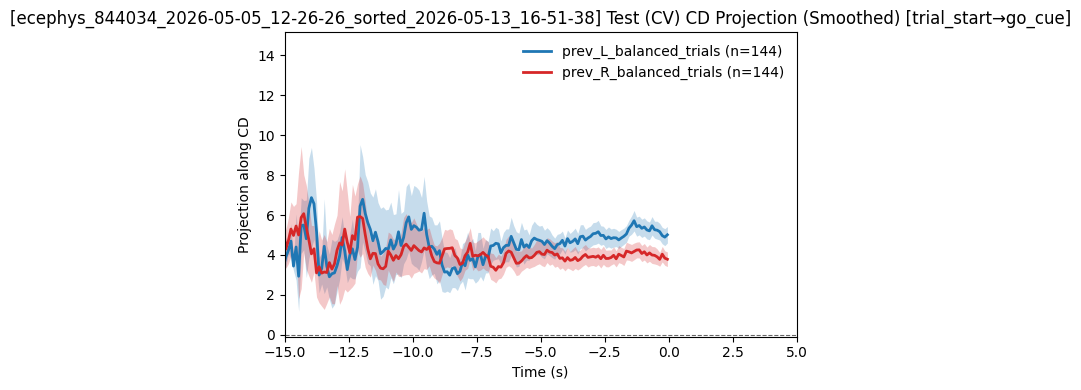

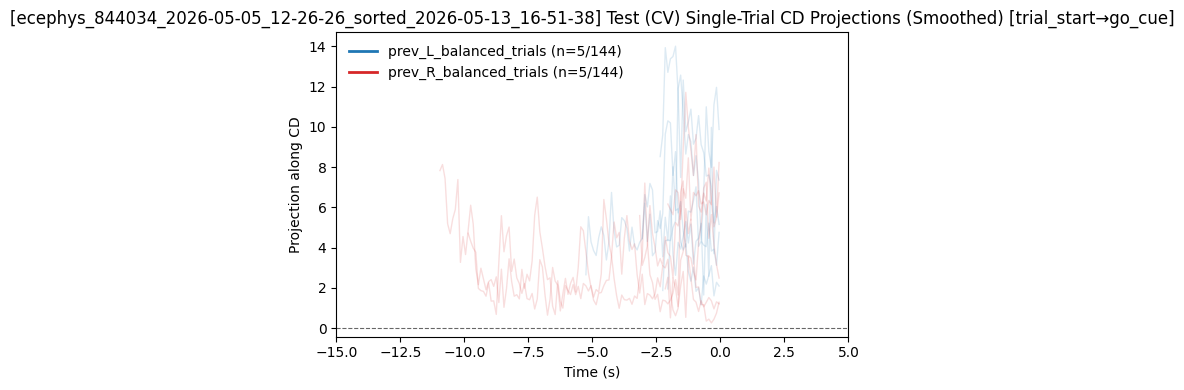

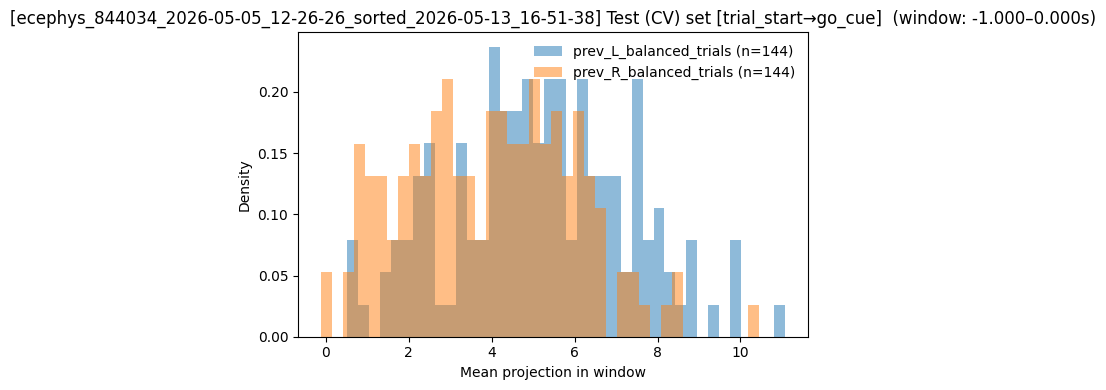

  --- axis = up_choice (up_L_balanced_trials vs up_R_balanced_trials) ---
Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-05_12-26-26.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-05_12-26-26.nwb


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:308: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:283: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/opt/conda/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


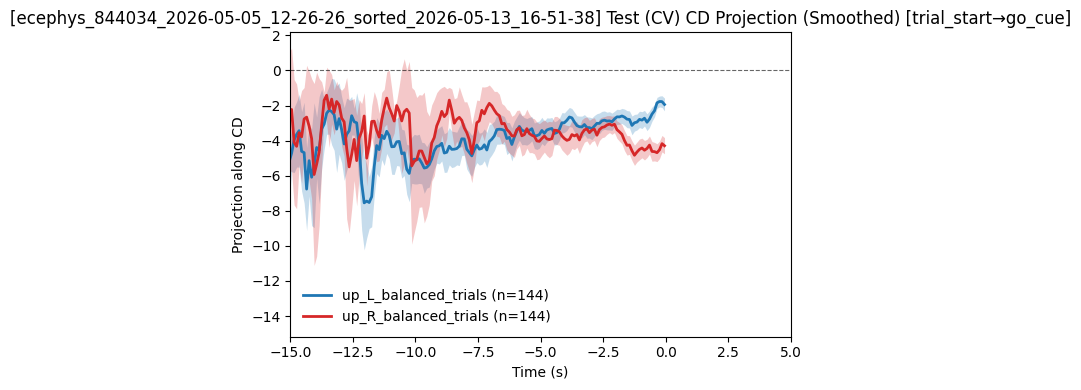

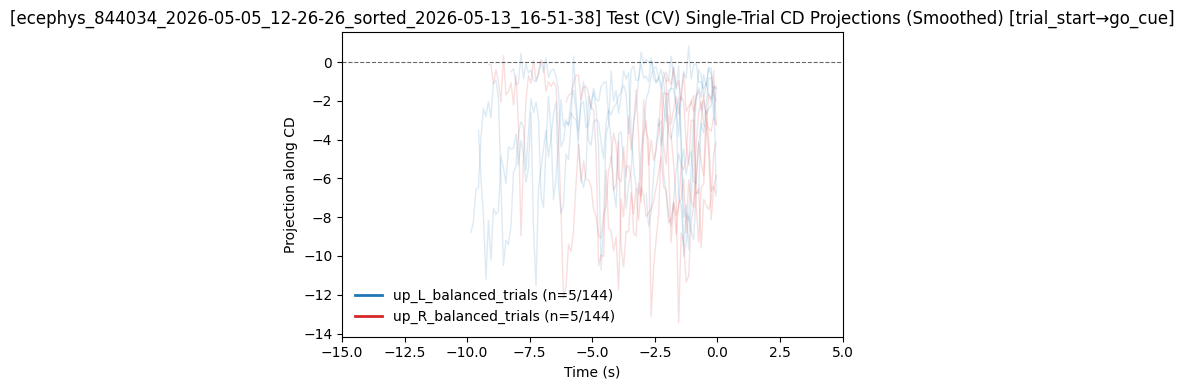

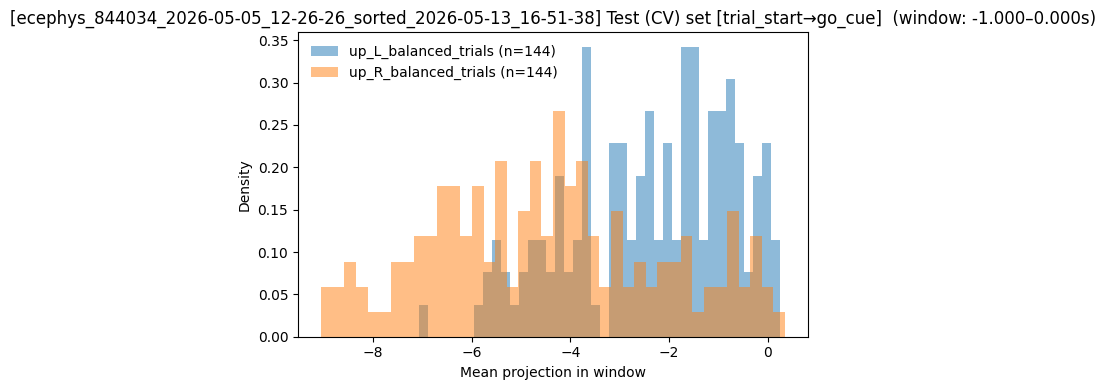

  --- axis = switch_stay (switch_balanced_trials vs stay_balanced_trials) ---
Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-05_12-26-26.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-05_12-26-26.nwb


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:308: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:283: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/opt/conda/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


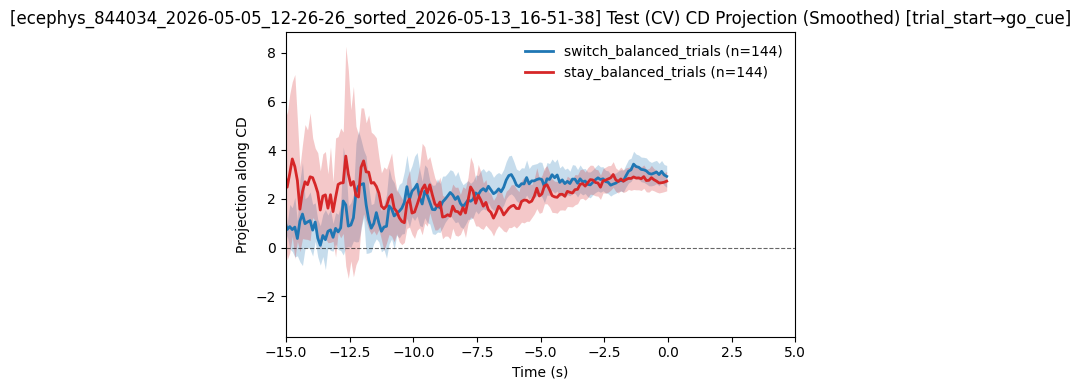

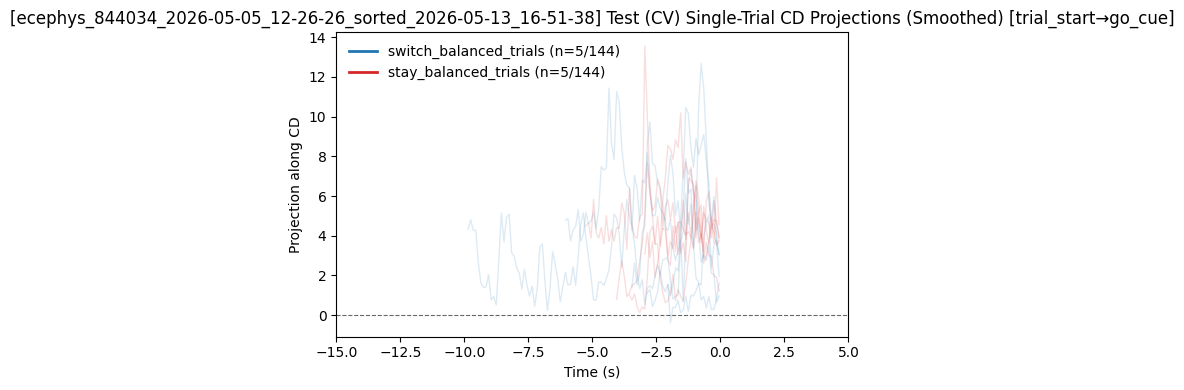

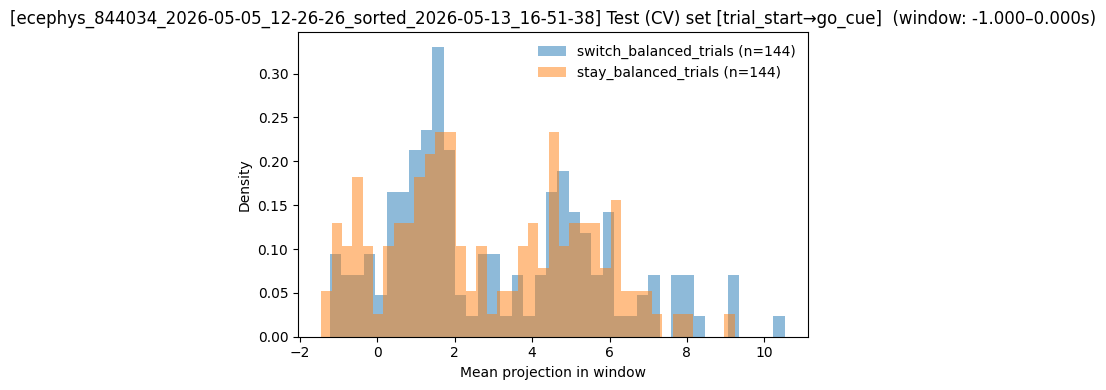

  --- axis = switch_dir (switch_LR_balanced_trials vs switch_RL_balanced_trials) ---
Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-05_12-26-26.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-05_12-26-26.nwb


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:308: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:283: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/opt/conda/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


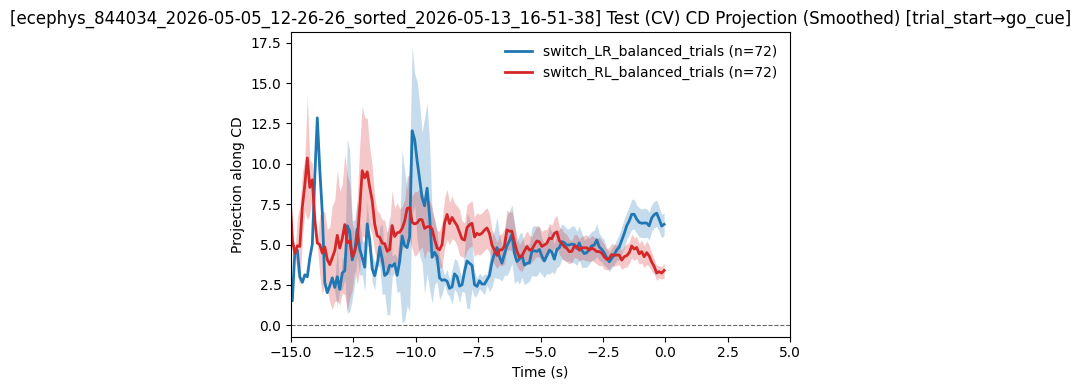

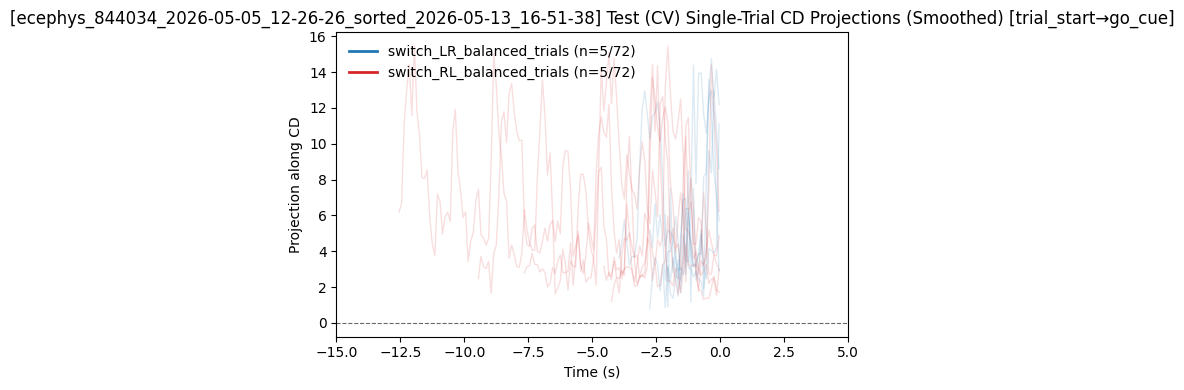

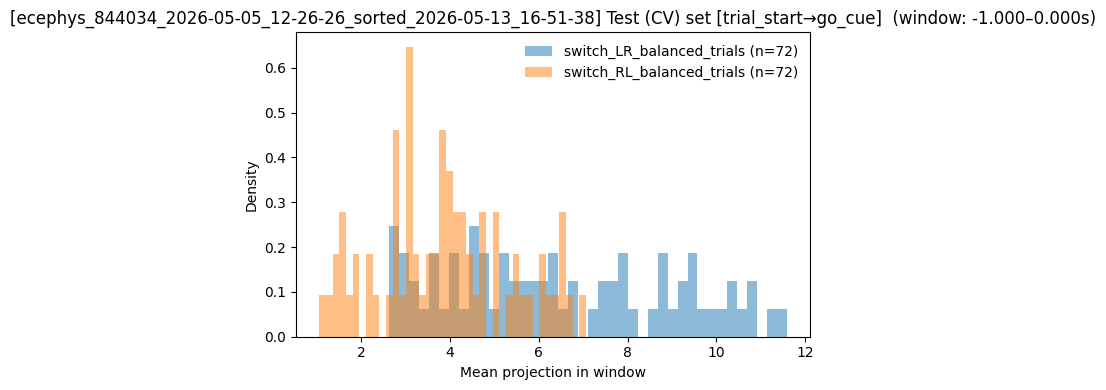


=========== Session: ecephys_844034_2026-05-06_12-31-42_sorted_2026-05-10_00-09-35 ===========
  --- axis = prev_choice (prev_L_balanced_trials vs prev_R_balanced_trials) ---
Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-06_12-31-42.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-06_12-31-42.nwb


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:308: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:283: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/opt/conda/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


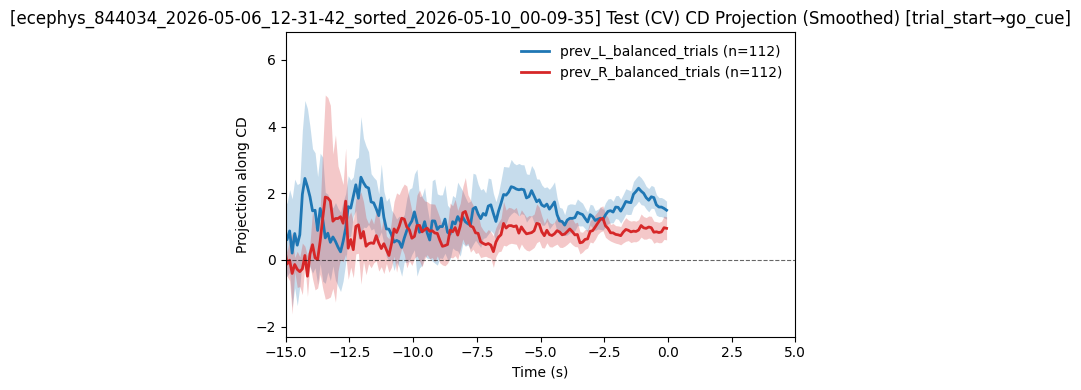

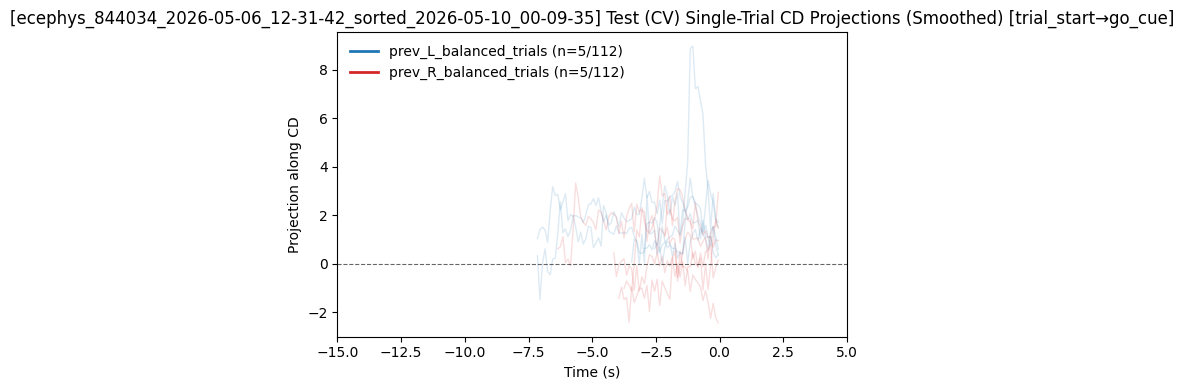

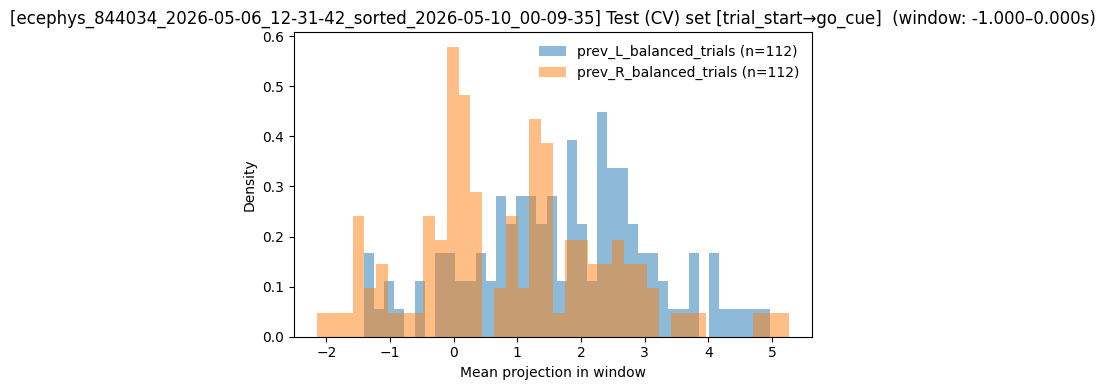

  --- axis = up_choice (up_L_balanced_trials vs up_R_balanced_trials) ---
Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-06_12-31-42.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-06_12-31-42.nwb


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:308: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:283: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/opt/conda/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


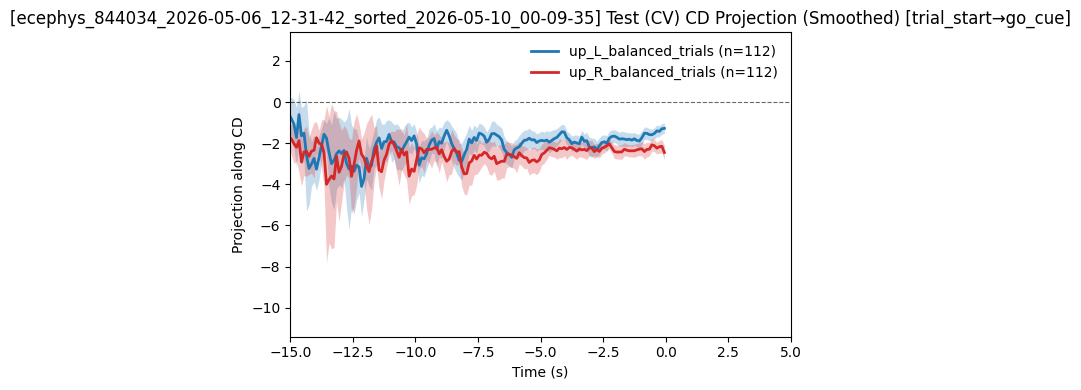

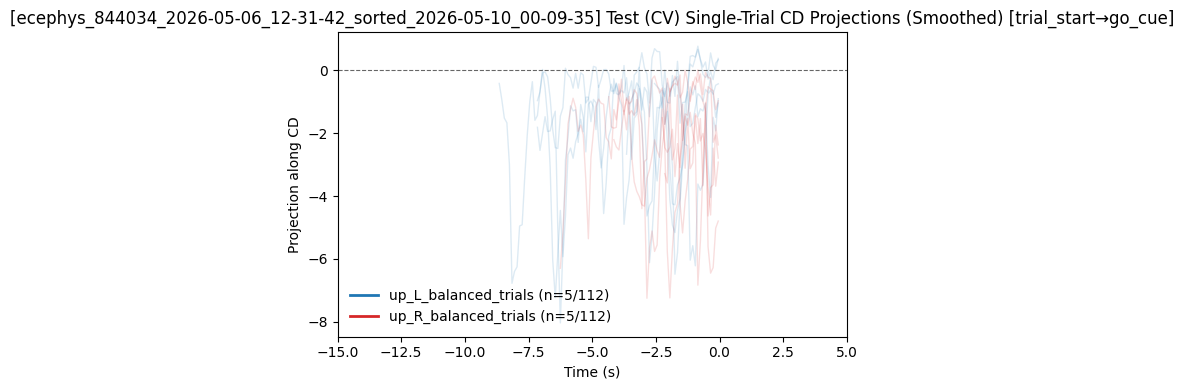

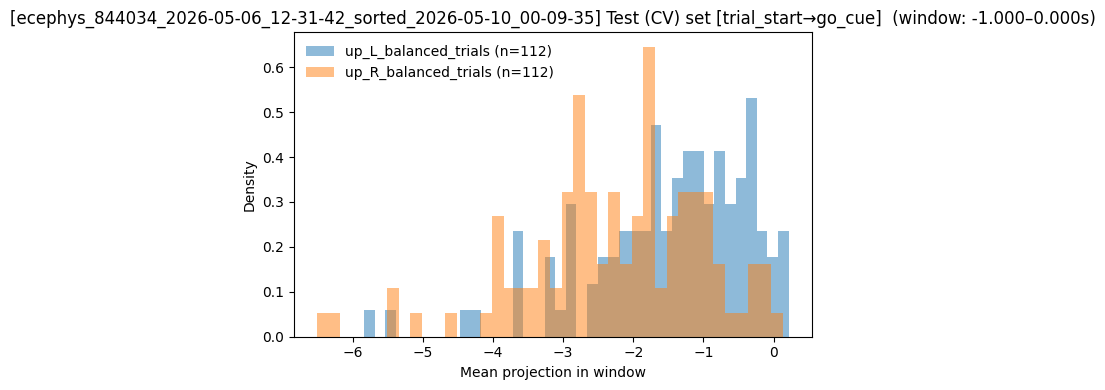

  --- axis = switch_stay (switch_balanced_trials vs stay_balanced_trials) ---
Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-06_12-31-42.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-06_12-31-42.nwb


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:308: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:283: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/opt/conda/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


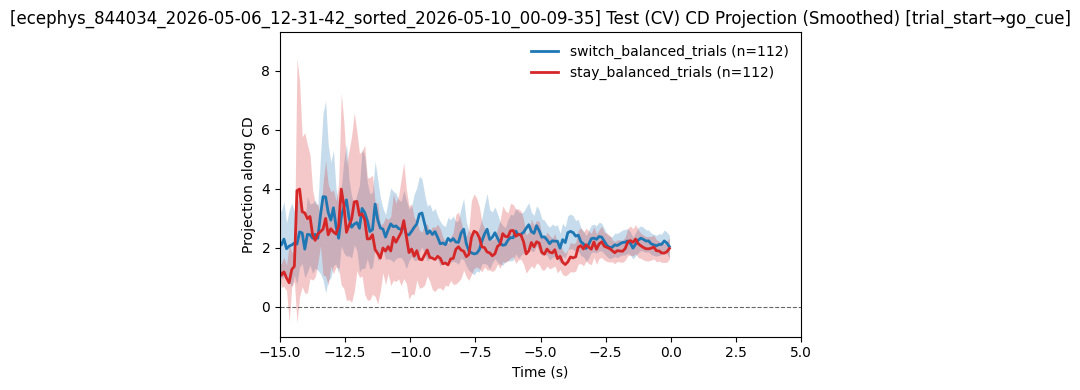

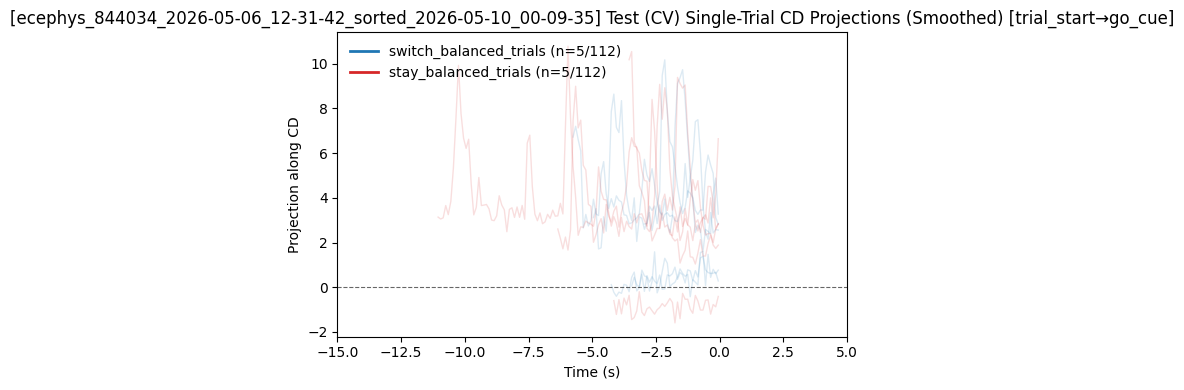

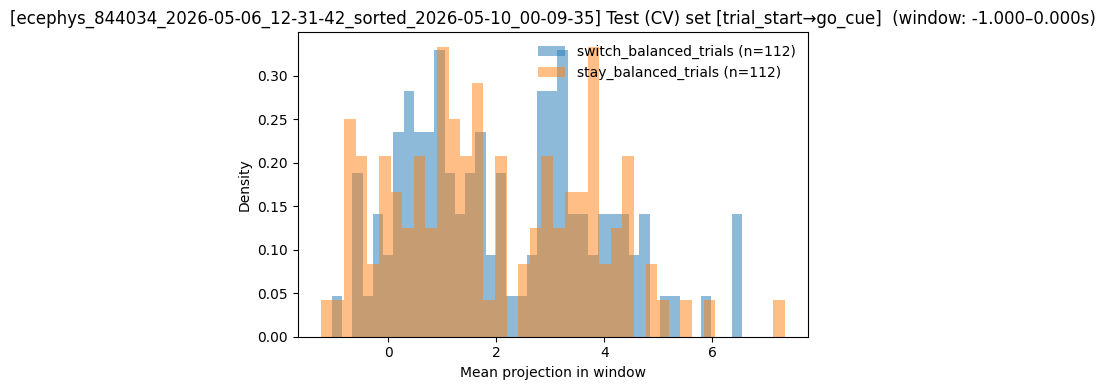

  --- axis = switch_dir (switch_LR_balanced_trials vs switch_RL_balanced_trials) ---
Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-06_12-31-42.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-06_12-31-42.nwb


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:308: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:283: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/opt/conda/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


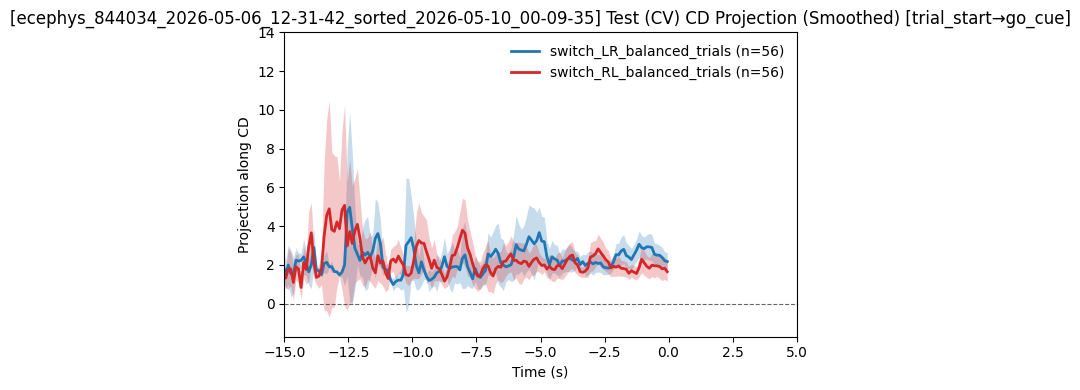

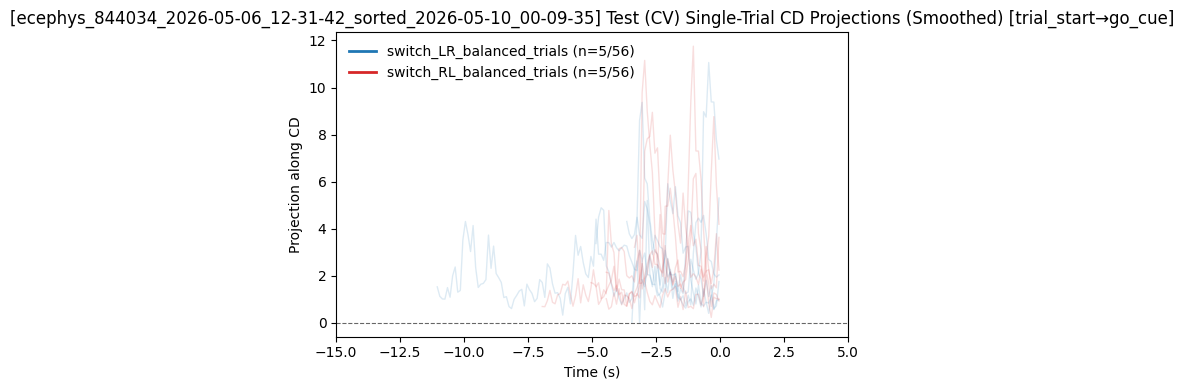

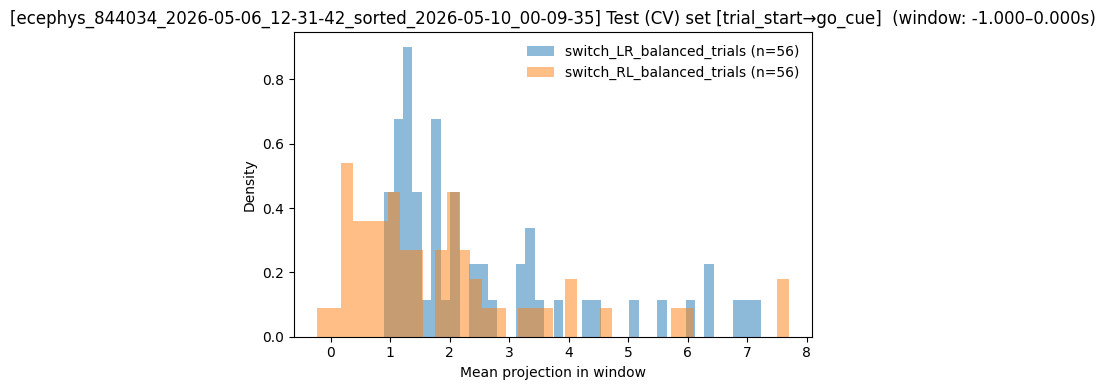


=========== Session: ecephys_844034_2026-05-07_12-26-08_sorted_2026-05-10_22-15-43 ===========
  --- axis = prev_choice (prev_L_balanced_trials vs prev_R_balanced_trials) ---
Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-07_12-26-08.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-07_12-26-08.nwb


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:308: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:283: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/opt/conda/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


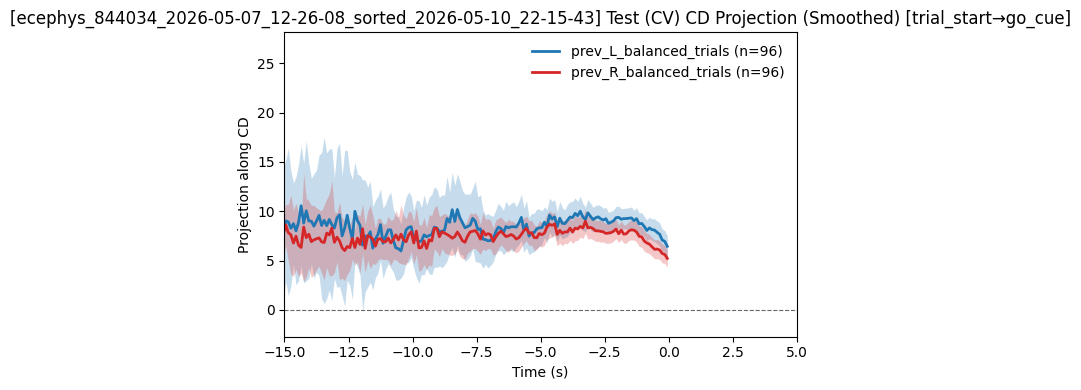

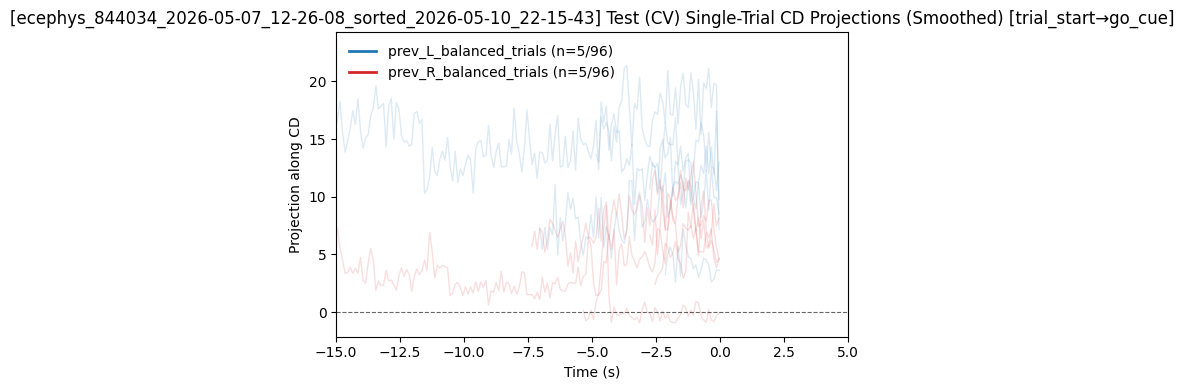

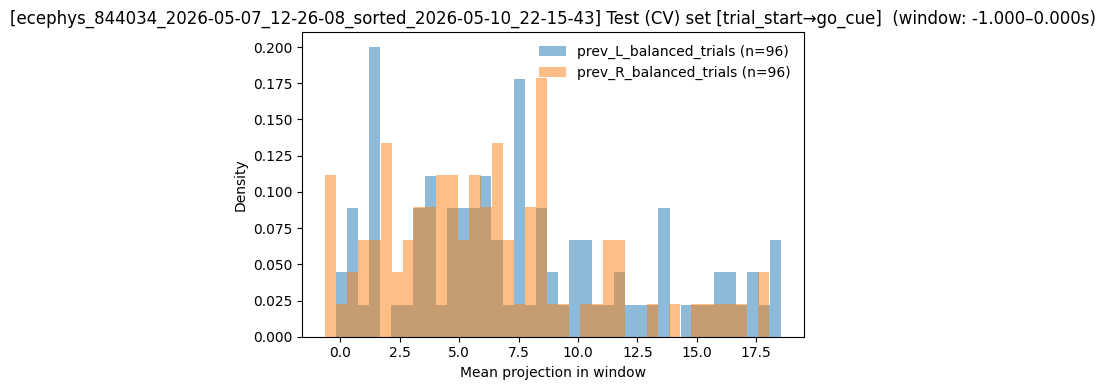

  --- axis = up_choice (up_L_balanced_trials vs up_R_balanced_trials) ---
Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-07_12-26-08.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-07_12-26-08.nwb


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:308: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:283: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/opt/conda/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


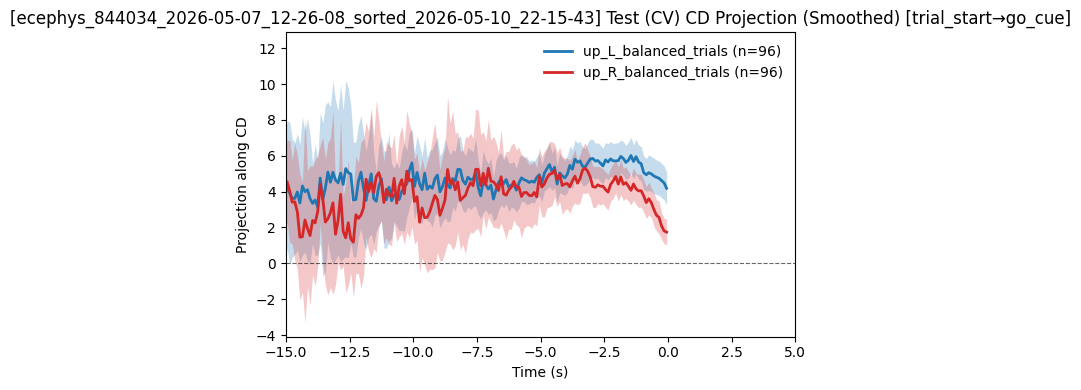

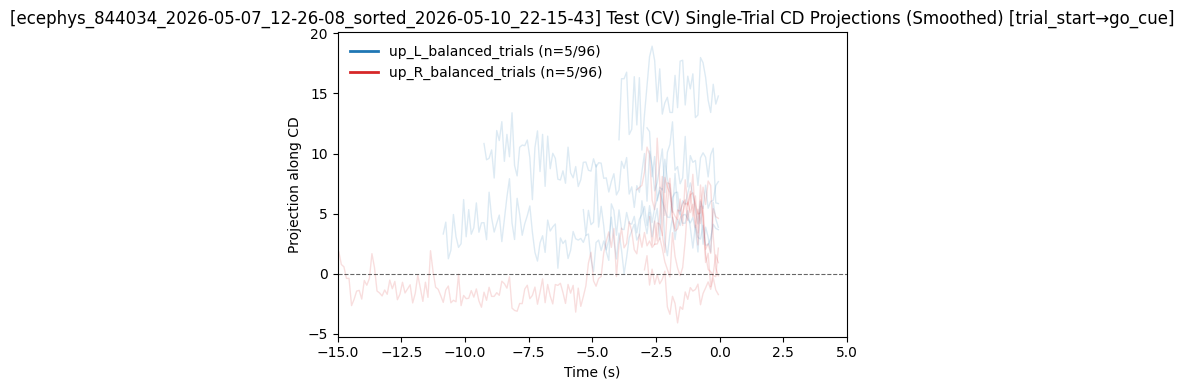

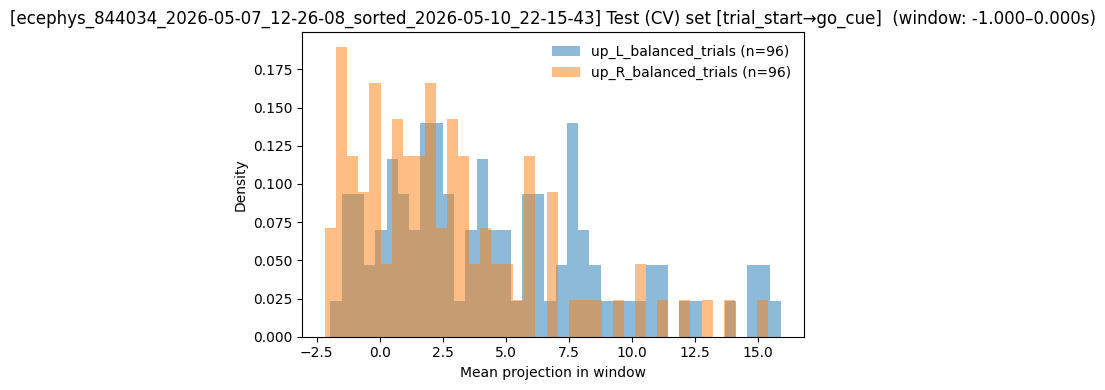

  --- axis = switch_stay (switch_balanced_trials vs stay_balanced_trials) ---
Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-07_12-26-08.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-07_12-26-08.nwb


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:308: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:283: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/opt/conda/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


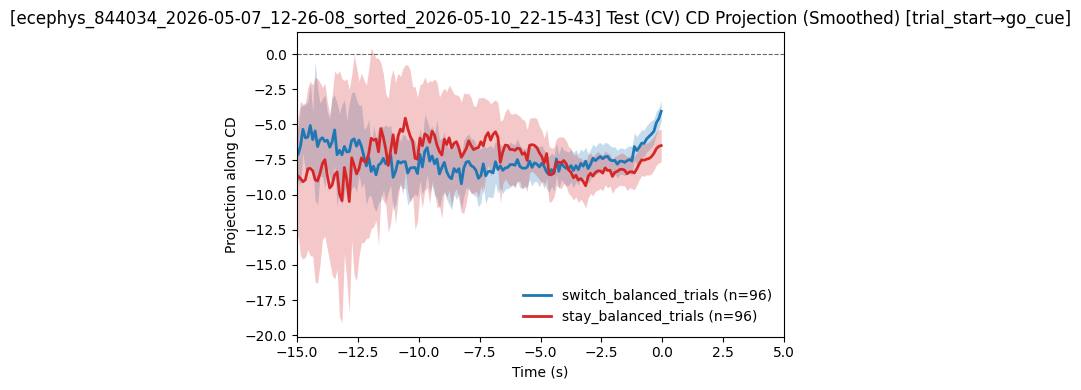

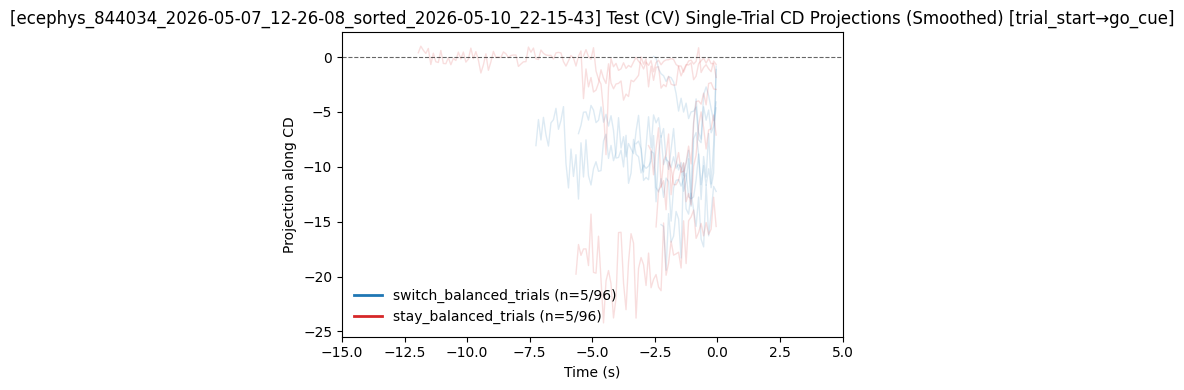

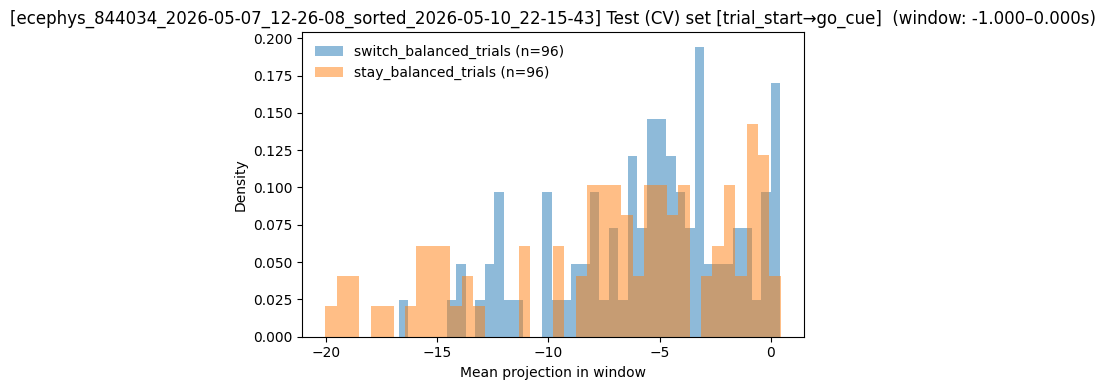

  --- axis = switch_dir (switch_LR_balanced_trials vs switch_RL_balanced_trials) ---
Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-07_12-26-08.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-07_12-26-08.nwb


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:308: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:283: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/opt/conda/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


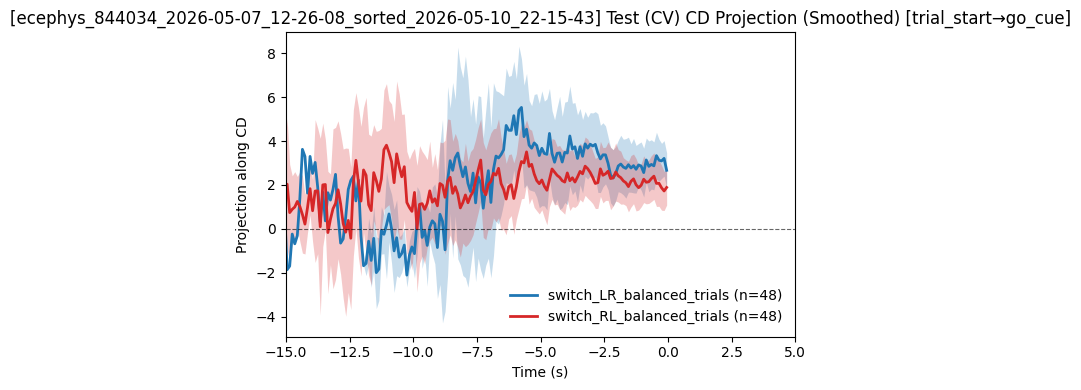

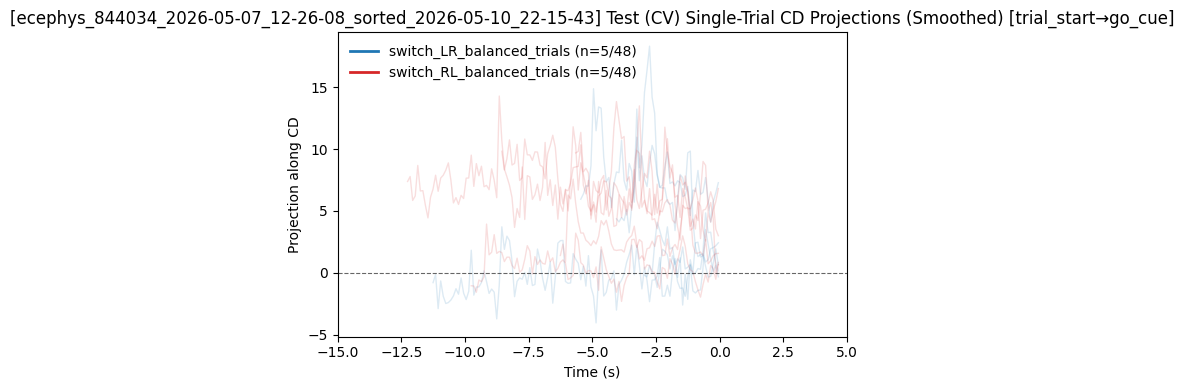

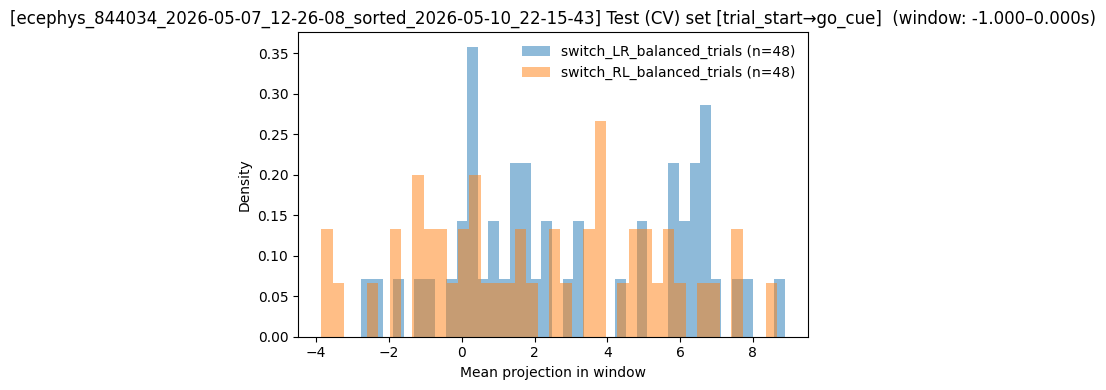


=========== Session: ecephys_844036_2026-05-04_16-06-43_sorted_2026-05-09_21-00-45 ===========
  --- axis = prev_choice (prev_L_balanced_trials vs prev_R_balanced_trials) ---
Found behavior NWB: /root/capsule/data/behavior_nwb/844036_2026-05-04_16-06-43.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844036_2026-05-04_16-06-43.nwb


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:308: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:283: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/opt/conda/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


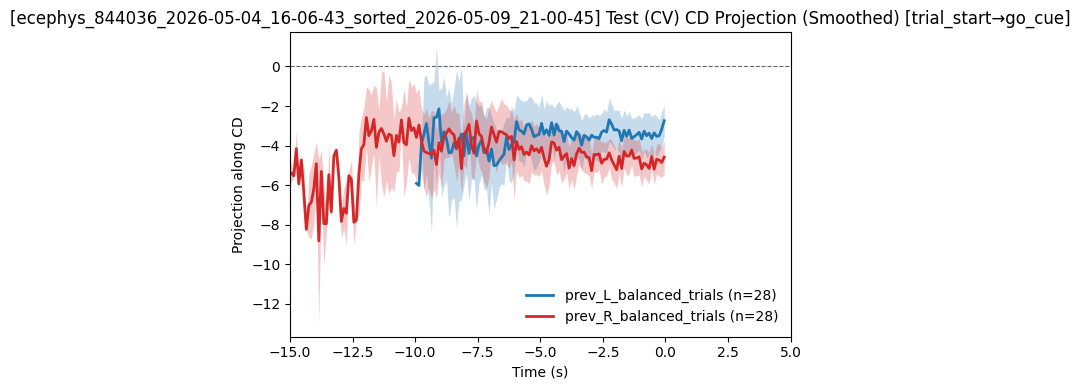

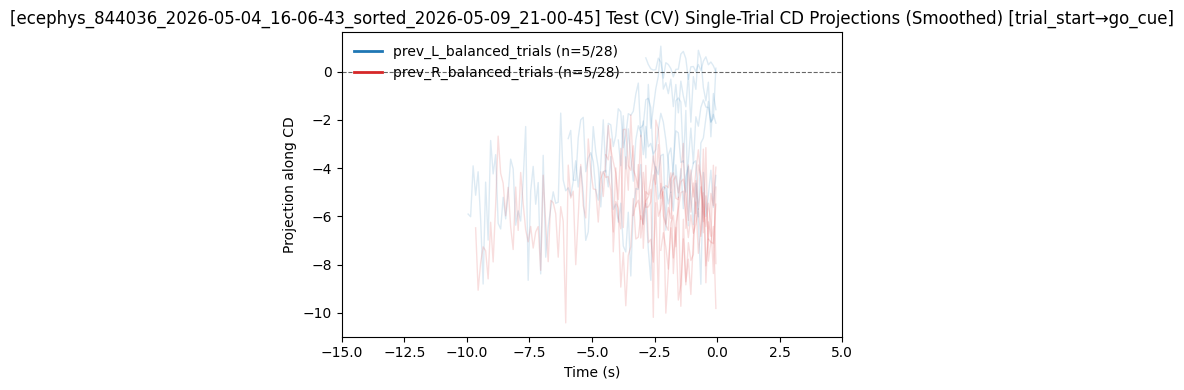

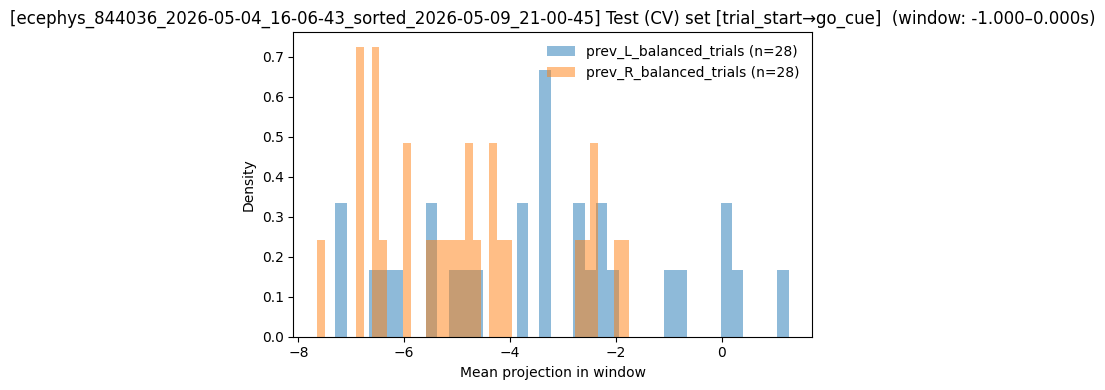

  --- axis = up_choice (up_L_balanced_trials vs up_R_balanced_trials) ---
Found behavior NWB: /root/capsule/data/behavior_nwb/844036_2026-05-04_16-06-43.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844036_2026-05-04_16-06-43.nwb


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:308: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:283: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/opt/conda/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


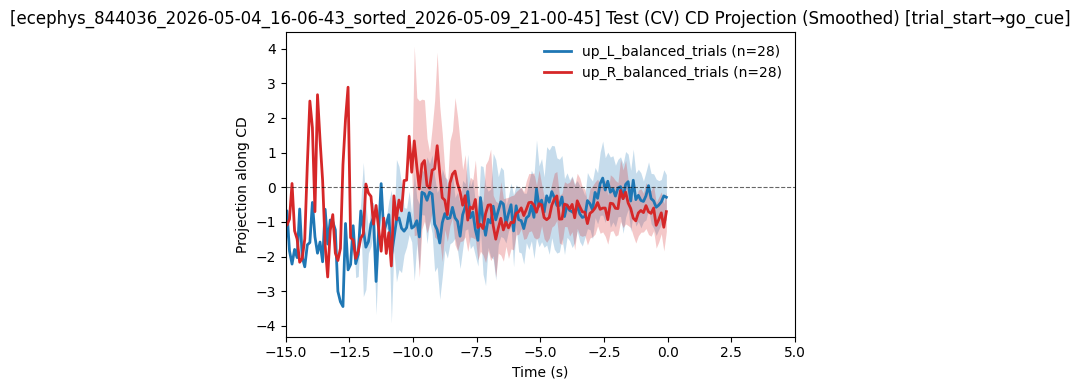

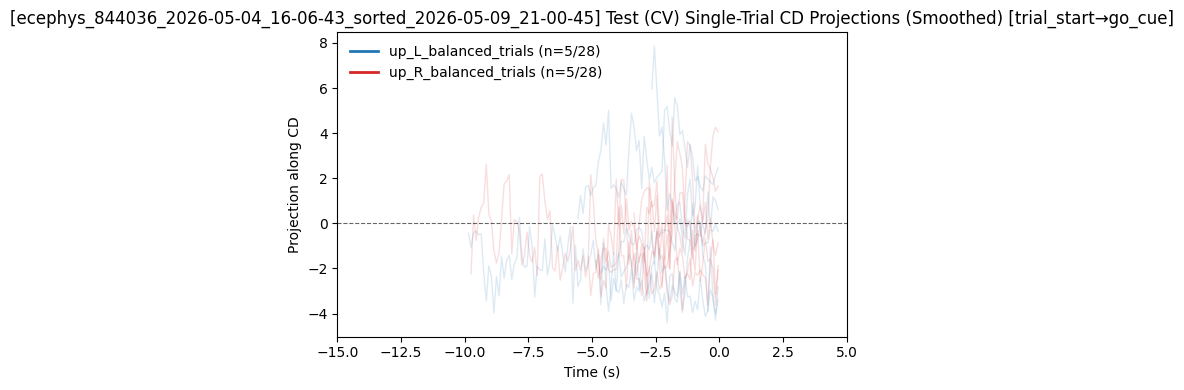

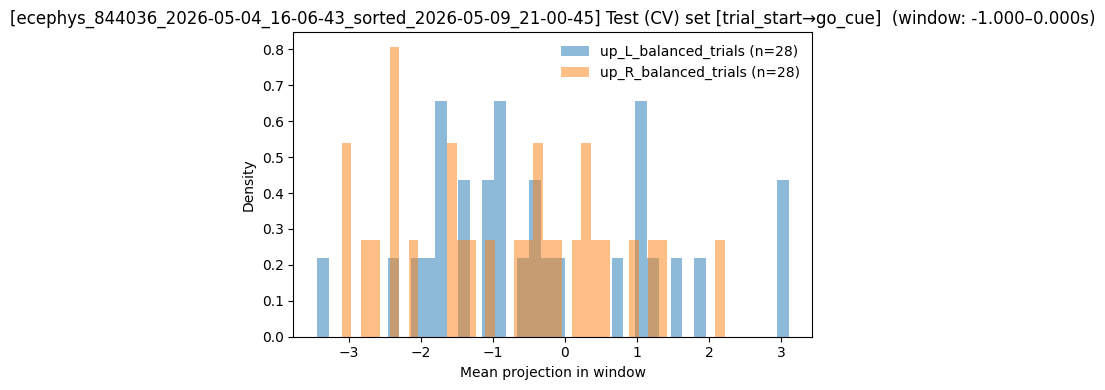

  --- axis = switch_stay (switch_balanced_trials vs stay_balanced_trials) ---
Found behavior NWB: /root/capsule/data/behavior_nwb/844036_2026-05-04_16-06-43.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844036_2026-05-04_16-06-43.nwb


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:308: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:283: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/opt/conda/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


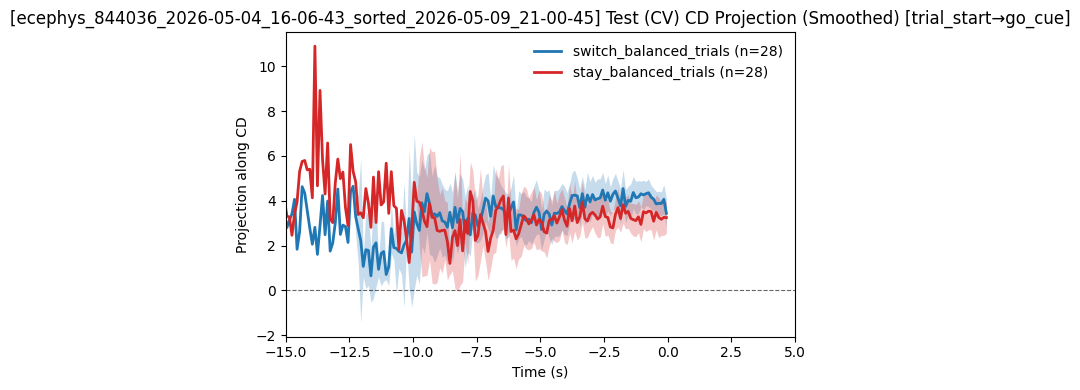

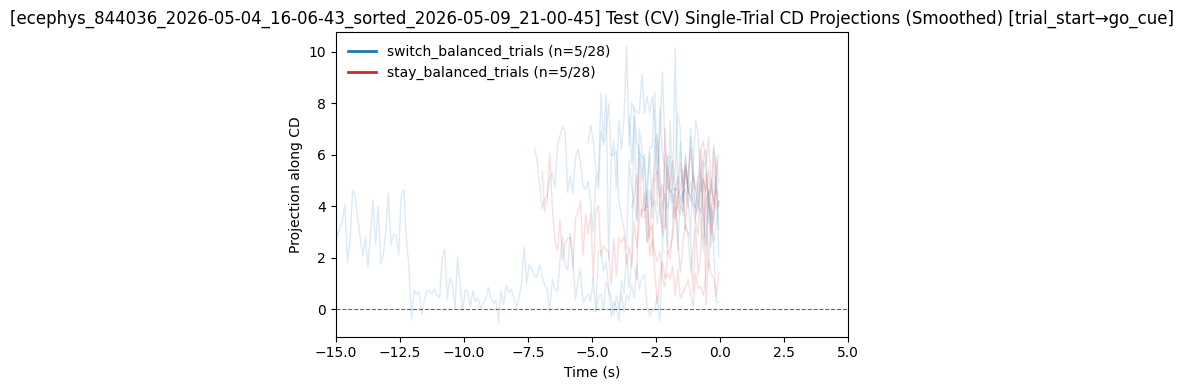

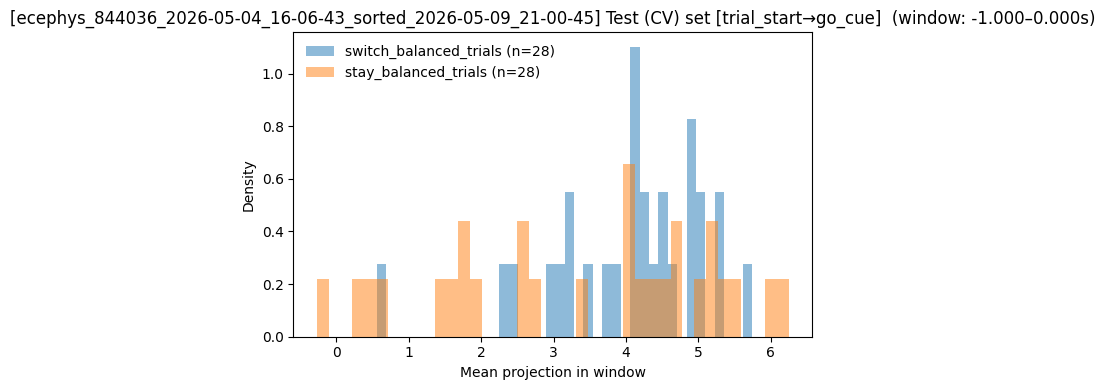

  --- axis = switch_dir (switch_LR_balanced_trials vs switch_RL_balanced_trials) ---
Found behavior NWB: /root/capsule/data/behavior_nwb/844036_2026-05-04_16-06-43.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844036_2026-05-04_16-06-43.nwb


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:308: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:283: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/opt/conda/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


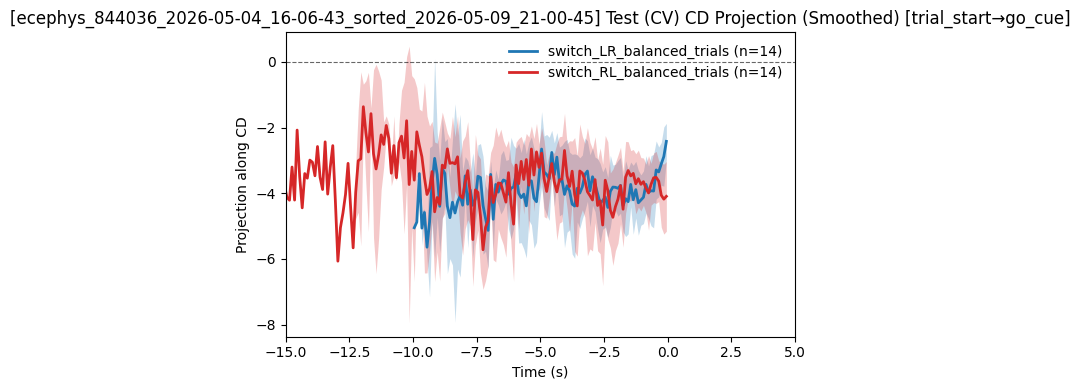

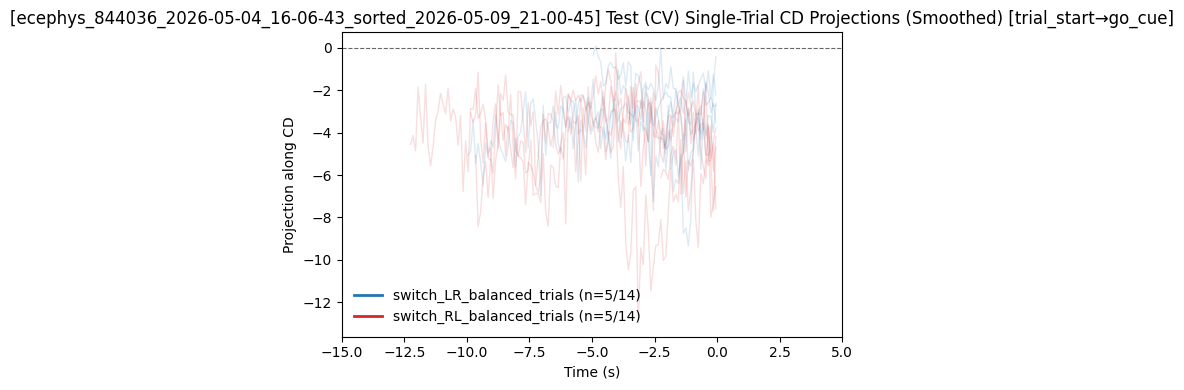

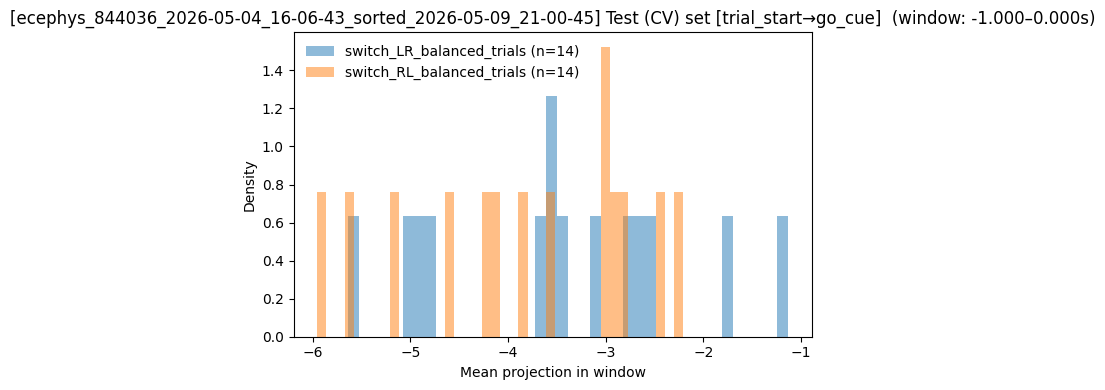


=========== Session: ecephys_844036_2026-05-05_16-08-08_sorted_2026-05-19_17-42-51 ===========
  --- axis = prev_choice (prev_L_balanced_trials vs prev_R_balanced_trials) ---
Found behavior NWB: /root/capsule/data/behavior_nwb/844036_2026-05-05_16-08-08.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844036_2026-05-05_16-08-08.nwb


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:308: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:283: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/opt/conda/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


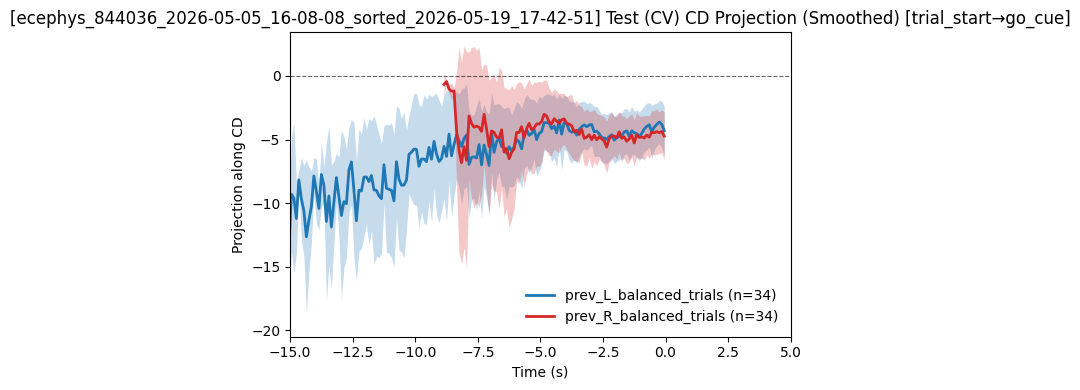

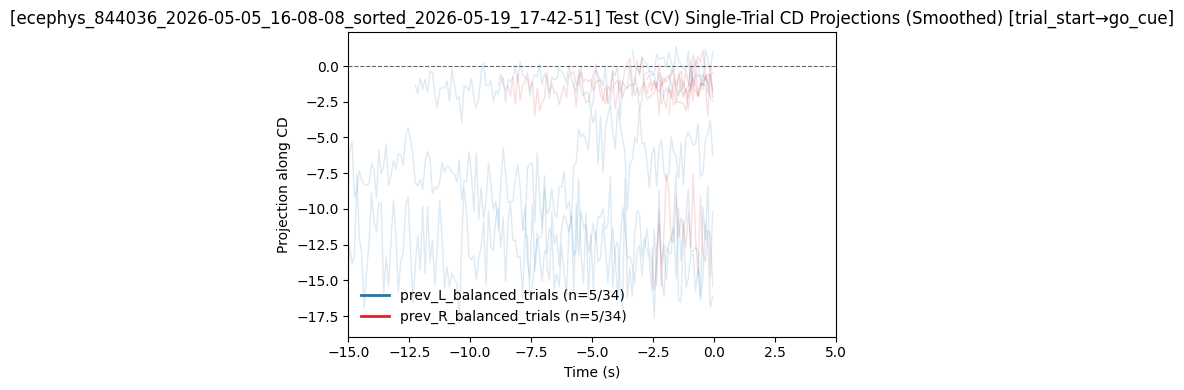

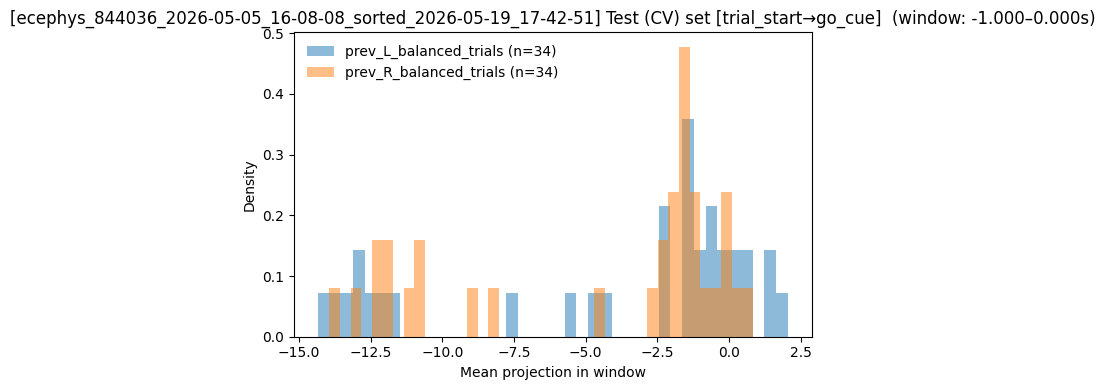

  --- axis = up_choice (up_L_balanced_trials vs up_R_balanced_trials) ---
Found behavior NWB: /root/capsule/data/behavior_nwb/844036_2026-05-05_16-08-08.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844036_2026-05-05_16-08-08.nwb


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:308: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:283: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/opt/conda/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


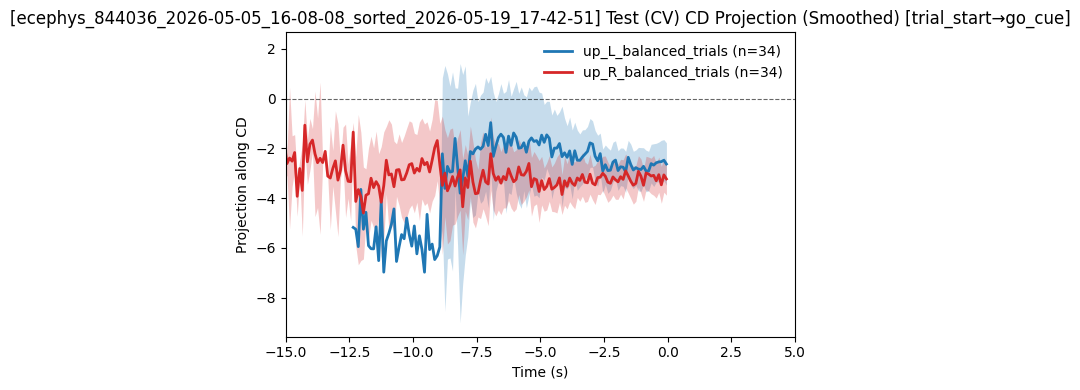

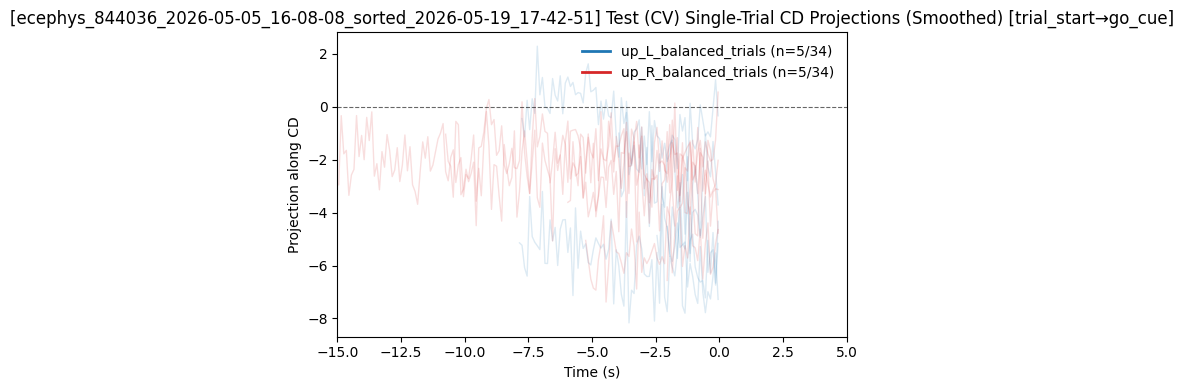

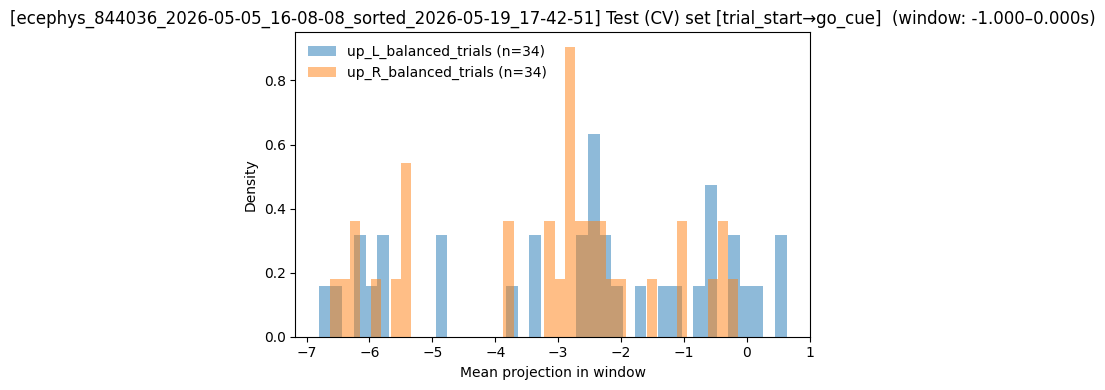

  --- axis = switch_stay (switch_balanced_trials vs stay_balanced_trials) ---
Found behavior NWB: /root/capsule/data/behavior_nwb/844036_2026-05-05_16-08-08.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844036_2026-05-05_16-08-08.nwb


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:308: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:283: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/opt/conda/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


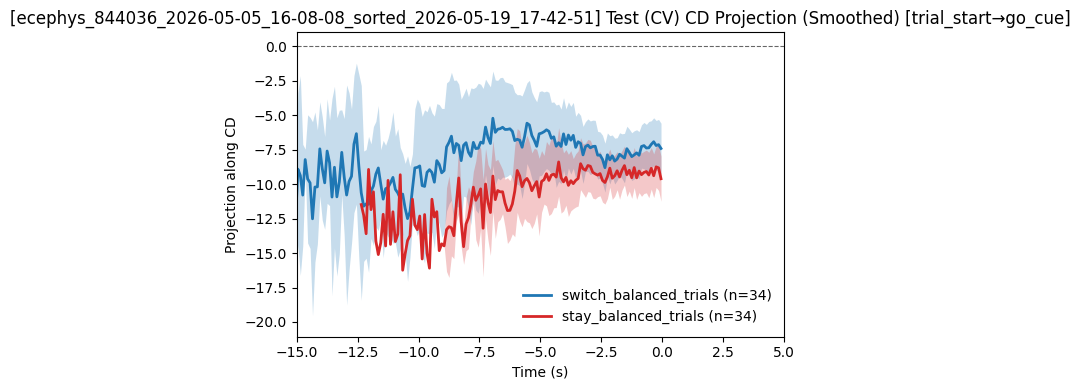

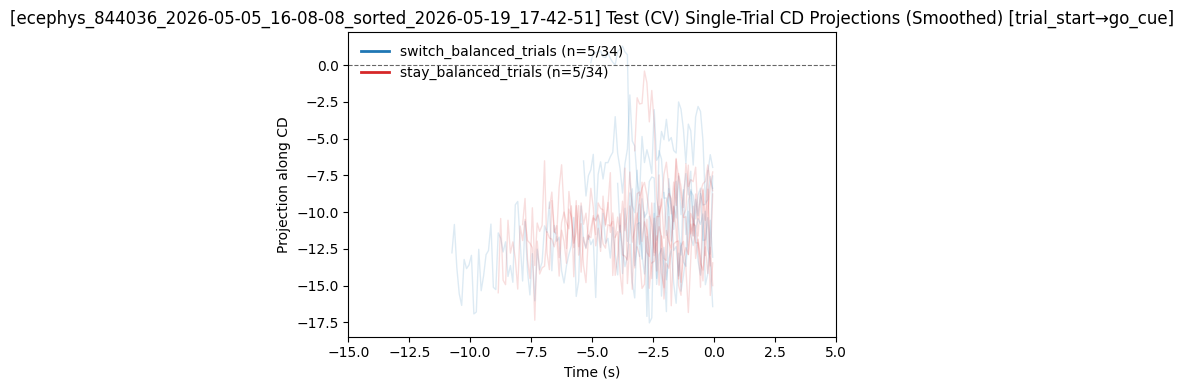

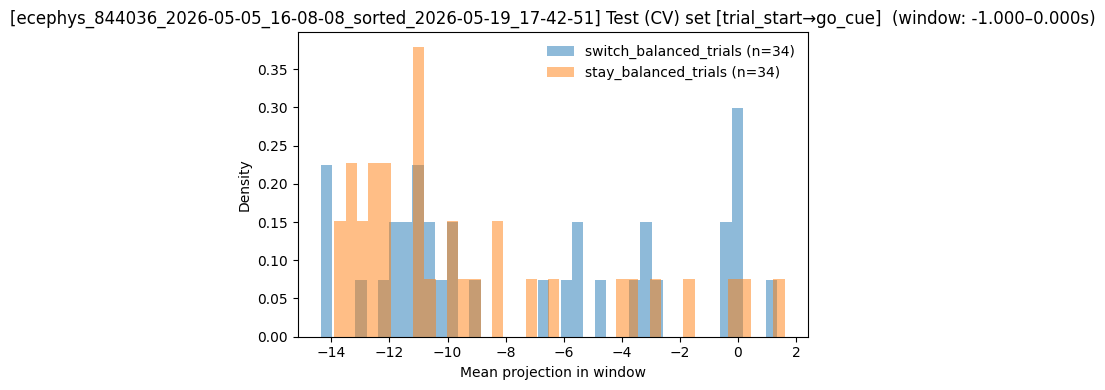

  --- axis = switch_dir (switch_LR_balanced_trials vs switch_RL_balanced_trials) ---
Found behavior NWB: /root/capsule/data/behavior_nwb/844036_2026-05-05_16-08-08.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844036_2026-05-05_16-08-08.nwb


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:308: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:283: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/opt/conda/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


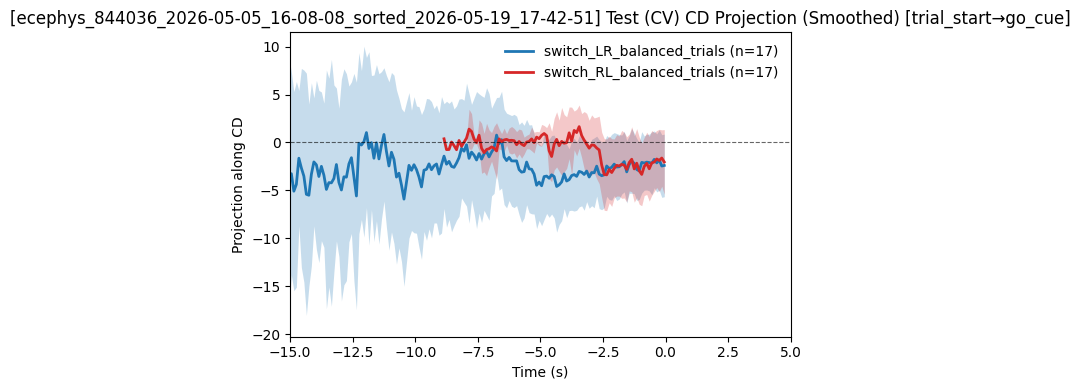

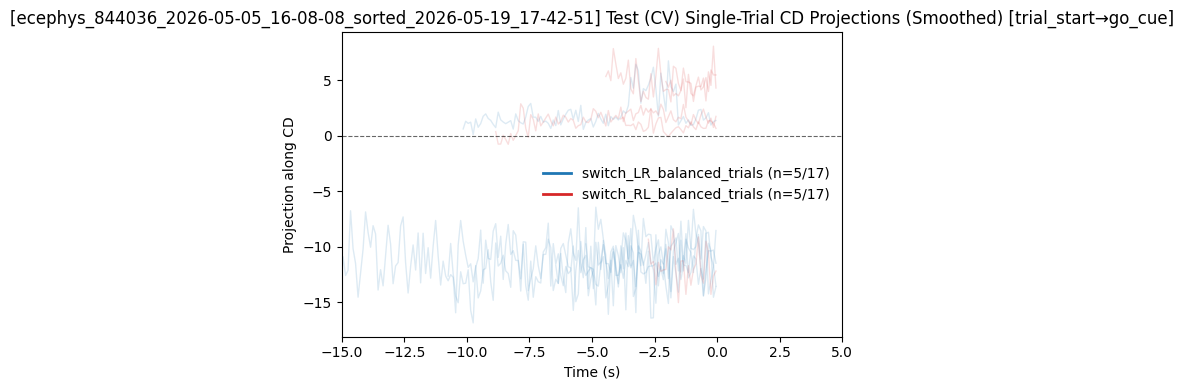

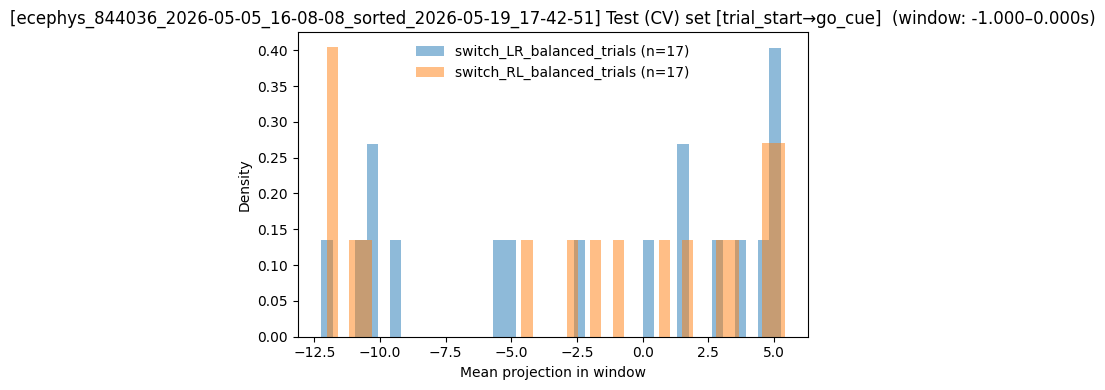


=========== Session: ecephys_844036_2026-05-06_16-27-46_sorted_2026-05-10_00-06-13 ===========
  --- axis = prev_choice (prev_L_balanced_trials vs prev_R_balanced_trials) ---
Found behavior NWB: /root/capsule/data/behavior_nwb/844036_2026-05-06_16-27-46.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844036_2026-05-06_16-27-46.nwb


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:308: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:283: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/opt/conda/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


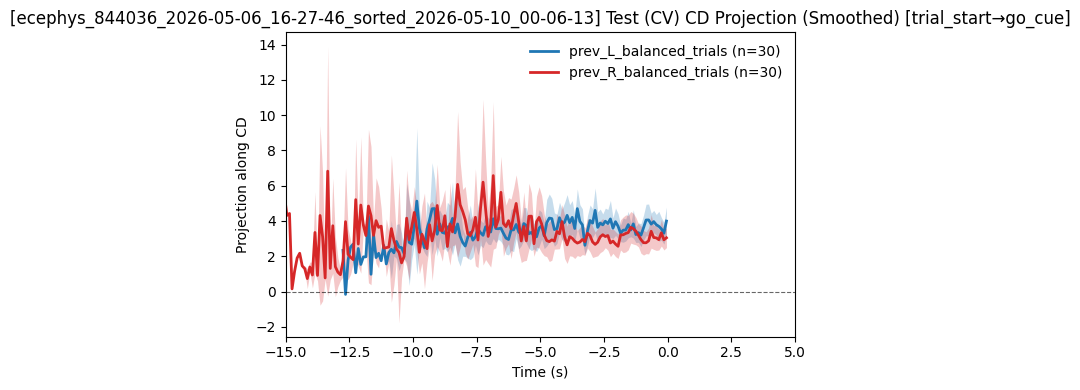

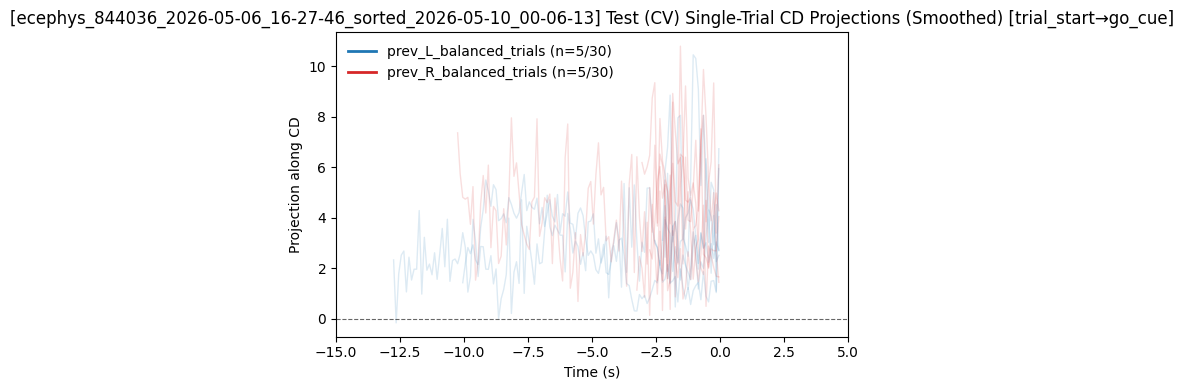

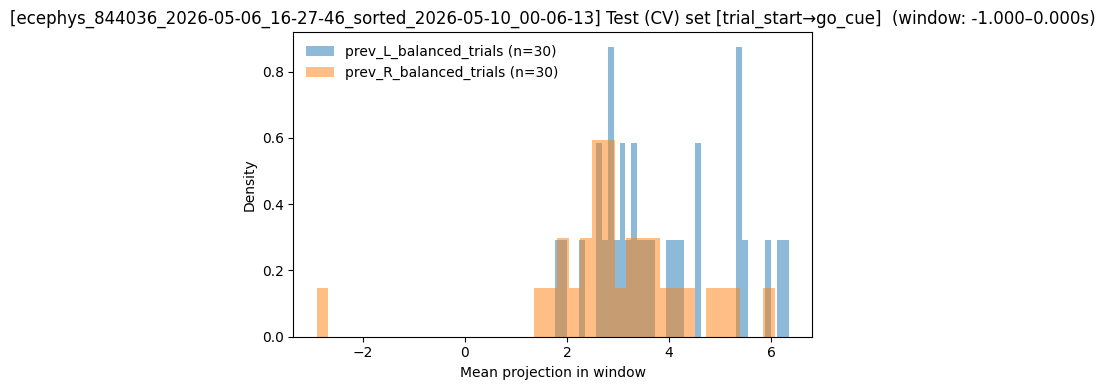

  --- axis = up_choice (up_L_balanced_trials vs up_R_balanced_trials) ---
Found behavior NWB: /root/capsule/data/behavior_nwb/844036_2026-05-06_16-27-46.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844036_2026-05-06_16-27-46.nwb


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:308: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:283: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/opt/conda/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


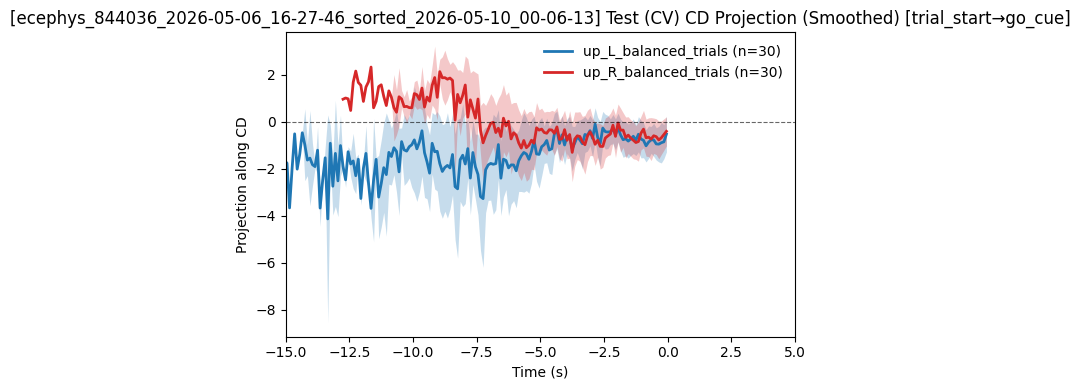

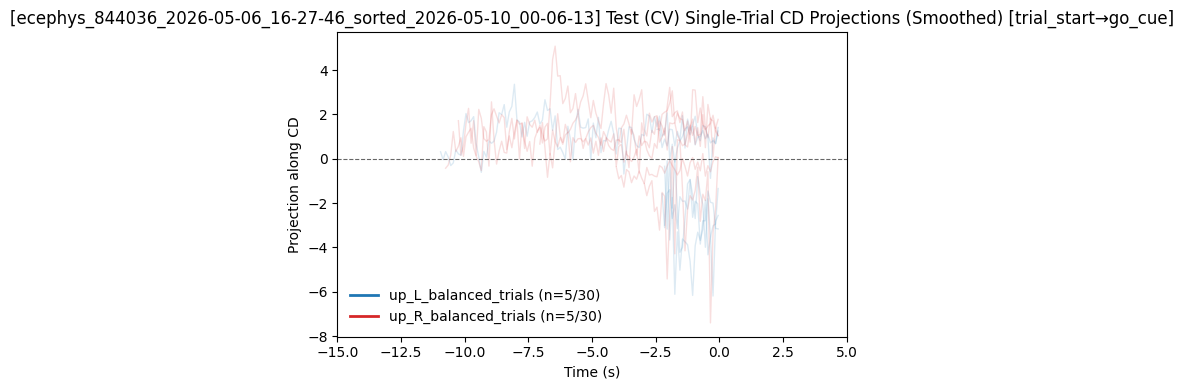

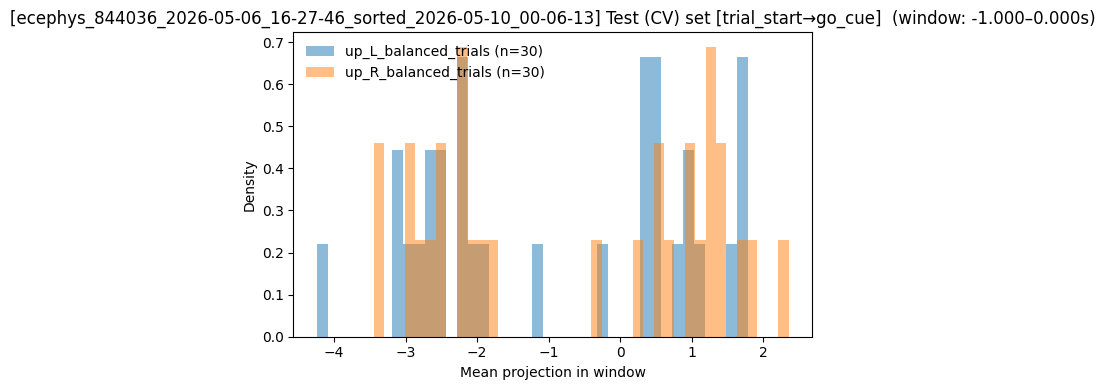

  --- axis = switch_stay (switch_balanced_trials vs stay_balanced_trials) ---
Found behavior NWB: /root/capsule/data/behavior_nwb/844036_2026-05-06_16-27-46.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844036_2026-05-06_16-27-46.nwb


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:308: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:283: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/opt/conda/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


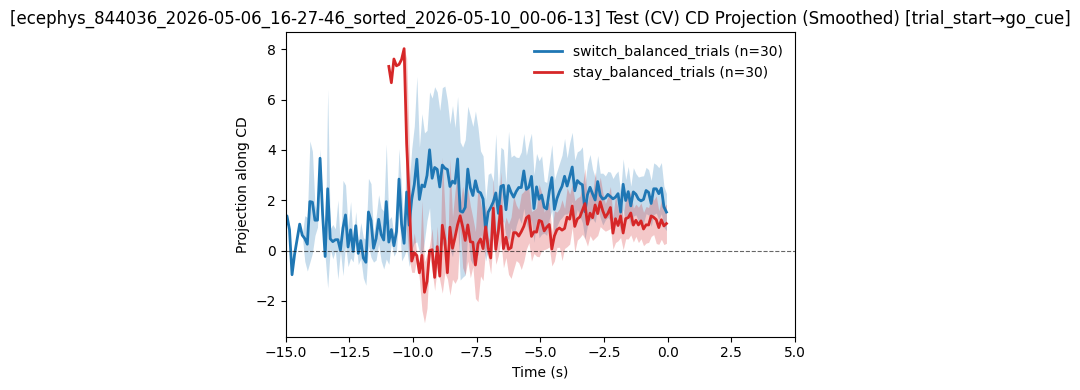

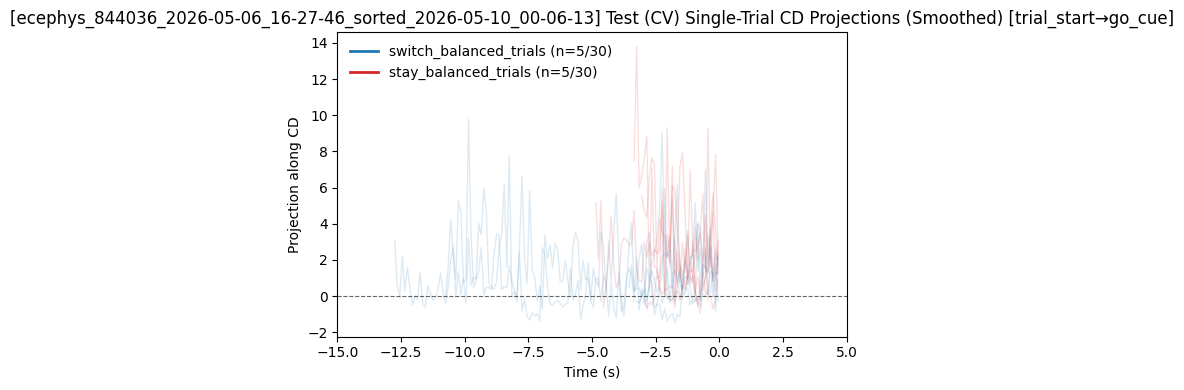

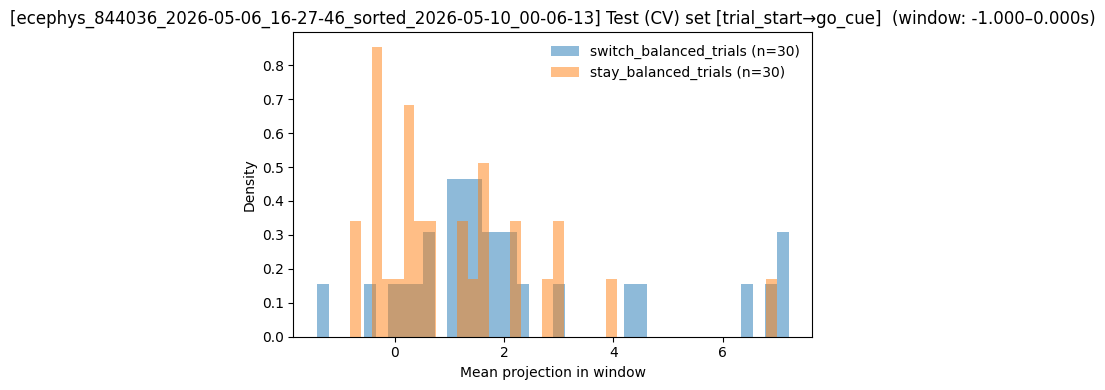

  --- axis = switch_dir (switch_LR_balanced_trials vs switch_RL_balanced_trials) ---
Found behavior NWB: /root/capsule/data/behavior_nwb/844036_2026-05-06_16-27-46.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844036_2026-05-06_16-27-46.nwb


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:308: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_visualization.py:283: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(traces, axis=0)
/opt/conda/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


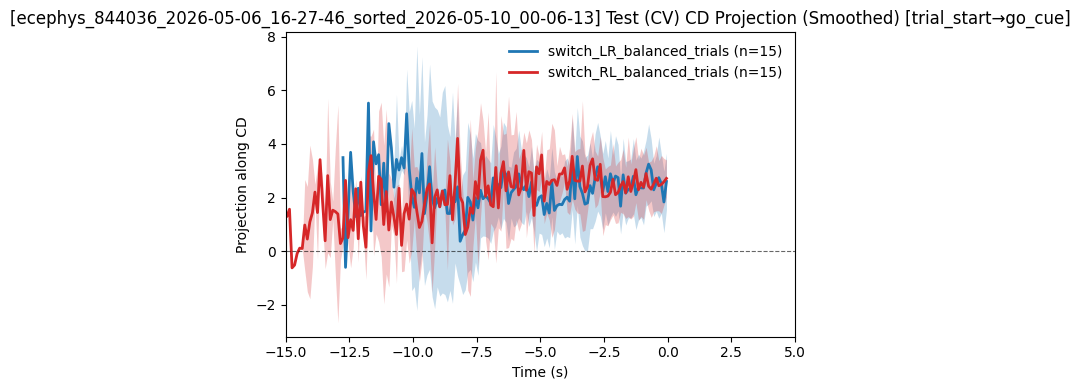

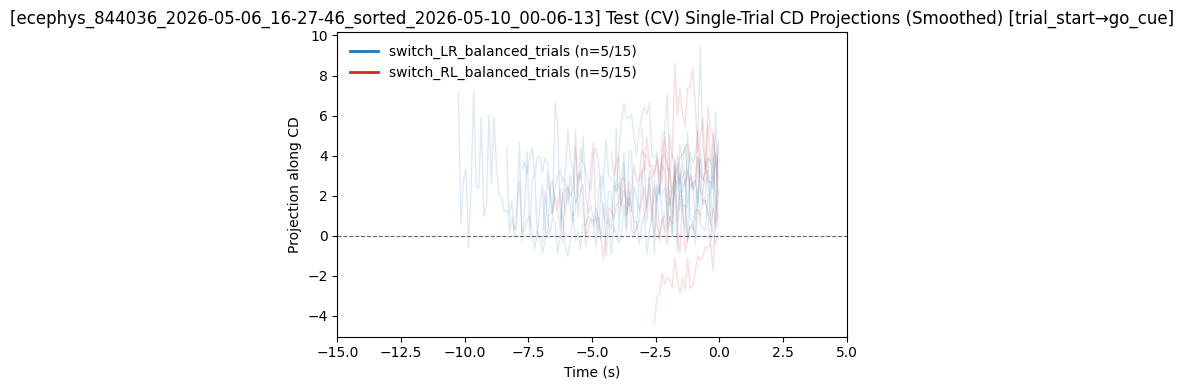

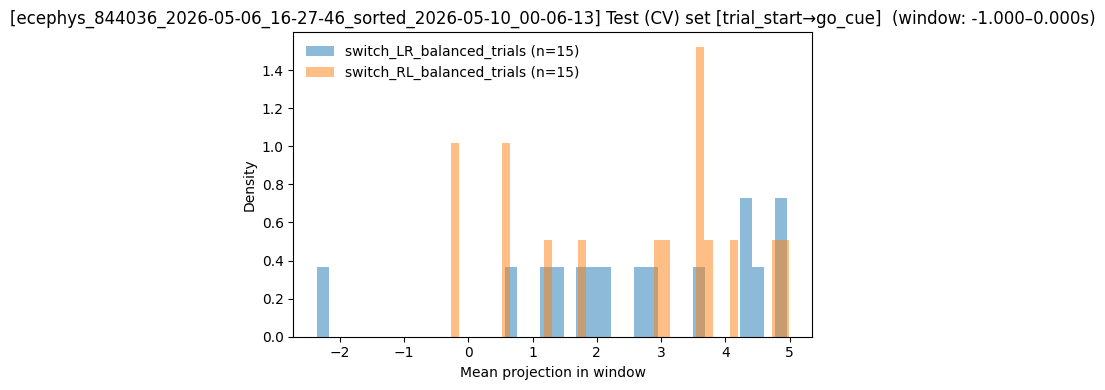

In [4]:
import os
from ephys_dimension_reduction_CD_pipeline import (
    cd_save_path,
    load_cd_session,
    plot_cd_session,
    region_label,
    ACTION_AXES,
)

viz_region_group     = []
viz_time_window      = (-1, 0)
distribution_window  = (-1, 0)
restrict_events      = ("trial_start", "go_cue")

region_lbl, region_print = region_label(viz_region_group)

# Column-name pairs that `_balance_action_cells` writes (must match the seed/suffix above).
axis_column_pairs = {
    "prev_choice":   (f"prev_L_{balance_suffix}_trials",   f"prev_R_{balance_suffix}_trials"),
    "up_choice":     (f"up_L_{balance_suffix}_trials",     f"up_R_{balance_suffix}_trials"),
    "switch_stay":   (f"switch_{balance_suffix}_trials",   f"stay_{balance_suffix}_trials"),
    "switch_dir":    (f"switch_LR_{balance_suffix}_trials", f"switch_RL_{balance_suffix}_trials"),
}

for session in sessions:
    beh_csv = os.path.join(behavior_root, f"behavior_summary-{session}.csv")
    if not os.path.exists(beh_csv):
        print(f"[skip] behavior CSV missing for {session}")
        continue
    print(f"\n=========== Session: {session} ===========")
    for axis, cols in axis_column_pairs.items():
        zpath = cd_save_path(
            cd_root, session, region_lbl, cols, viz_time_window, align=align,
        )
        if not zpath.exists():
            print(f"  [skip] {axis}: zarr not built ({zpath.name})")
            continue
        sess = load_cd_session(zpath, beh_csv)
        print(f"  --- axis = {axis} ({cols[0]} vs {cols[1]}) ---")
        plot_cd_session(
            sess,
            distribution_window=distribution_window,
            restrict_events=restrict_events,
            restrict_align=align,
            xlim=(-15, 5),
            split="test",
            smooth_gauss=0.0,
            smooth_moving_window=10,
            plot_single_trial=True,
            random_sample_trial_N=5,
        )

## 3. Project all 4 cells onto each axis

For each axis, project the four 2×2 cells (`L_L`, `switch_LR`, `switch_RL`, `R_R`) onto its CD axis. `plot_cd_session(trial_types=...)` accepts at most 2 columns at a time, so we render two figures per axis — one for stays (`L_L` vs `R_R`) and one for switches (`switch_LR` vs `switch_RL`) — together covering all four cells.

Reading the result: on the `prev_choice` axis, prev-L cells (`L_L`, `switch_LR`) should separate from prev-R cells (`switch_RL`, `R_R`) regardless of upcoming choice; on `up_choice`, the split should follow the upcoming side; etc.

In [ ]:
# Pairs of cells to overlay per axis (need 1 or 2 cols per plot_cd_session call)
cell_pairs = [
    (f"L_L_{balance_suffix}_trials",       f"R_R_{balance_suffix}_trials"),        # stays
    (f"switch_LR_{balance_suffix}_trials", f"switch_RL_{balance_suffix}_trials"),  # switches
]

for session in sessions:
    beh_csv = os.path.join(behavior_root, f"behavior_summary-{session}.csv")
    if not os.path.exists(beh_csv):
        continue
    print(f"\n=========== Session: {session} ===========")
    for axis, cols in axis_column_pairs.items():
        zpath = cd_save_path(
            cd_root, session, region_lbl, cols, viz_time_window, align=align,
        )
        if not zpath.exists():
            continue
        sess = load_cd_session(zpath, beh_csv)
        for pair_name, pair_cols in zip(("stays", "switches"), cell_pairs):
            print(f"  axis = {axis} | {pair_name}: {pair_cols[0]} vs {pair_cols[1]}")
            plot_cd_session(
                sess,
                distribution_window=distribution_window,
                restrict_events=restrict_events,
                restrict_align=align,
                xlim=(-15, 5),
                split="test",
                smooth_gauss=0.0,
                smooth_moving_window=10,
                plot_single_trial=True,
                random_sample_trial_N=5,
                trial_types=list(pair_cols),
            )


=========== Session: ecephys_844034_2026-05-05_12-26-26_sorted_2026-05-13_16-51-38 ===========
  axis = prev_choice: 4-cell projections


ValueError: trial_types must contain 1 or 2 column names.